
# Same Patient, Different Explanations?

### A Comparative Study to evaluate SHAP's Consistency Across ML Models in healthcare.

This project provides a systematic, empirical test. We train two structurally different models (XGBoost and a multilayer perceptron) on four healthcare datasets spanning two diseases, generate SHAP explanations for each, and measure whether those explanations agree — globally and at the individual patient level. By replicating the comparison across two diabetes datasets and two heart disease datasets, we can determine whether any divergence pattern is a property of the model architecture, the dataset, or both.

**Resaerch Question**

When two structurally different machine learning models are trained on the same healthcare dataset and explained with SHAP, do they provide the same account of why a given prediction was made — and does any observed divergence replicate across different healthcare prediction tasks?

**Sub-Questions**

1.	Within-dataset: Do the models agree on which features drive predictions, both globally (feature rankings) and locally (individual patients)?
2.	Cross-dataset within disease: Does the pattern of agreement or divergence replicate across two different datasets for the same disease? For example, if XGBoost and MLP diverge on Pima Diabetes, do they also diverge on the Kaggle Diabetes Prediction dataset?
3.	Cross-disease: Is the divergence pattern consistent across disease domains (diabetes vs heart disease), or is it disease-specific?
4.	Governance implications: If explanations diverge, how must we re-evaluate the definition of “regulatory transparency” in clinical AI deployment?



### Declaration of Generative AI Use

Generative AI (Claude Code) was used during the development of this notebook for (code formatting, syntax debugging). Project design, core logic, Result interpretations, and final conclusions are the original work of ours and references use. Below are the references.

**References**

1. Breiman, L. (2001). Statistical Modeling: The Two Cultures (with comments and a rejoinder by the author). Statistical Science, 16(3), 199-231.
2. Watson, M., Awwad Shiekh Hasan, B., & Al Moubayed, N. (2022). Agree to Disagree: When Deep Learning Models With Identical Architectures - Produce Distinct Explanations. Proceedings of the IEEE/CVF Winter Conference on Applications of Computer Vision (WACV).
3. Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. Advances in Neural Information Processing Systems, 30.
4. Ramachandranpillai, R., Baeza-Yates, R., & Heintz, F. (2025). FairXAI — A Taxonomy and Framework for Fairness and Explainability Synergy in Machine Learning. IEEE Transactions on Neural Networks and Learning Systems, 36(6).
5. Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). “Why Should I Trust You?”: Explaining the Predictions of Any Classifier. Proceedings of KDD.
6. Kaggle - Pima Indians Diabetes Dataset, Heart Disease (Cleveland) Dataset, Diabetes_prediction, and Framingham (heart_disease_prediction). Note: the Framingham was initial cleaned in Google Colab before importing, here is the link to the Google colab: https://colab.research.google.com/drive/1GRcQZ9an3_w09oiY3ze21CMvI9pe9OAk#scrollTo=kNX_nANaWKr0
7. Sources on how to deal with Multicollinearity in our dataset which appear in cell7. https://www.kaggle.com/discussions/getting-started/560170

### Prerequisites & Setup

**Environment Requirements:**
This project requires a Python 3.8+ environment. To ensure strict reproducibility of the SHAP values and model weight initializations, random seeds have been fixed globally.

**System Architecture:**
The PyTorch MLP and XGBoost models are configured to run on a standard CPU environment, though the PyTorch implementation can automatically leverage CUDA if a compatible GPU is detected.

**Required Libraries:**
Ensure the following packages are installed in your environment before execution:
`pip install pandas numpy matplotlib seaborn scikit-learn xgboost torch shap`

**Execution Instructions:**
1. Ensure the referenced healthcare datasets are downloaded and accessible in the correct relative filepath.
2. Execute the "Initialization: Library Imports" cell to load all dependencies.
3. Run the notebook sequentially from top to bottom. The notebook is strictly modular, meaning the data cleaning steps must be preserved in memory before model training and explainer initialization can occur.

### Cell 1: Dependencies

In [1]:
# Install dependencies needed for PyTorch, SHAP, and XGBoost
%pip install -q torch shap scipy xgboost scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =====================================================================
# Initialization: Library Imports & Environment Setup
# =====================================================================

# Data Manipulation & Visualization
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pathlib import Path
from typing import Dict, Any, Tuple
from typing import Dict, List, Tuple
from typing import Dict
from typing import Dict, List, Any, Optional
from dataclasses import dataclass
from typing import Any
from scipy.stats import mannwhitneyu

# Machine Learning & Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
import xgboost as xgb

# Deep Learning Architecture
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import Any
from scipy.stats import spearmanr

# Explainable AI (XAI)
import shap

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Cell 2: Initialization & Data Loading

This Python script is responsible for initializing the workspace, defining file paths, loading multiple datasets into memory, and outputting a high-level summary of the loaded data.

In [3]:
# It imports necessary data science and visualization libraries along with system libraries. 
# It also sets a default visual theme for plots using seaborn
sns.set_theme(style="whitegrid")
base_dir = Path.cwd()

# and wrapped each raw string (r"...") in a Path() object.
datasets = {
    "Pima Diabetes": {
        "csv": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\data\raw\Pima Indians Diabetes Dataset.csv"),
        "doc": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\doc\Pima Indians Diabetes columns meaning.txt")
    },
    "diabetes_prediction": {
        "csv": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\data\raw\diabetes_prediction_dataset.csv"),
        "doc": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\doc\Diabetes prediction dataset columns meaning.txt")
    },
    "uci_heart": {
        "csv": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\data\raw\UCI Heart Disease.csv"),
        "doc": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\doc\UCI Heart Disease Dataset column meaning.txt")
    },
    "heart_disease_prediction": {
        "csv": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\data\raw\Heart Disease prediction dataset.csv"),
        "doc": Path(r"c:\Users\pc\Downloads\shap-consistency-healthcare\doc\heart disease prediction dataset column meaning.txt")
    },
}

# It iterates through the datasets dictionary. For each dataset, it checks if the CSV file exists at the specified path.
loaded = {}
for name, paths in datasets.items():
    # Now paths["csv"] is a Path object, so .exists() will work perfectly
    if not paths["csv"].exists():
        raise FileNotFoundError(f"Missing file: {paths['csv']}")
    loaded[name] = pd.read_csv(paths["csv"])

# Summary Output
display(pd.DataFrame({
    "dataset": list(loaded.keys()),
    "rows": [df.shape[0] for df in loaded.values()],
    "cols": [df.shape[1] for df in loaded.values()],
}))

,dataset,rows,cols
0,Pima Diabetes,768,9
1,diabetes_prediction,100000,9
2,uci_heart,1025,14
3,heart_disease_prediction,4238,16


### Cell 3: Dataset Preview

This code block performs an automated, initial exploratory data analysis (EDA) for each dataset loaded into the notebook's memory.

In [4]:
# For each loaded dataset, it prints the first 5 rows and the data types of each column.

for name, df in loaded.items():
    print(f"\n=== {name} ===")
    display(df.head(5))
    display(df.dtypes.to_frame(name="dtype"))

# It checks for the existence of a documentation file that explains the meaning of each column and prints a preview of its contents if found.
    doc_path = datasets[name]["doc"]
    if Path(doc_path).exists():
        print(f"\nColumn meanings file: {Path(doc_path).name}")
        with open(doc_path, "r", encoding="utf-8", errors="ignore") as f:
            preview = "".join(f.readlines()[:25])
        print(preview)
    else:
        print("No column-meaning documentation file found.")


=== Pima Diabetes ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Column meanings file: Pima Indians Diabetes columns meaning.txt
Pregnancies
Number of times pregnant

Glucose
Plasma glucose concentration a 2 hours in an oral glucose tolerance test

BloodPressure
Diastolic blood pressure (mm Hg)

SkinThickness
Triceps skin fold thickness (mm)

Insulin
2-Hour serum insulin (mu U/ml)

BMI
Body mass index (weight in kg/(height in m)^2)

DiabetesPedigreeFunction
Diabetes pedigree function

Age
Age (years)

Outcome


=== diabetes_prediction ===


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


...

,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Column meanings file: UCI Heart Disease Dataset column meaning.txt
age
age in years

sex
(1 = male; 0 = female)

cp
chest pain type

trestbps
resting blood pressure (in mm Hg on admission to the hospital)

chol
serum cholestoral in mg/dl

fbs
(fasting blood sugar &gt; 120 mg/dl) (1 = true; 0 = false)

restecg
resting electrocardiographic results

thalach
maximum heart rate achieved

exang


=== heart_disease_prediction ===


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


,dtype
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64



Column meanings file: heart disease prediction dataset column meaning.txt
Sex: male or female(Nominal)
• Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)
Behavioral
• Current Smoker: whether or not the patient is a current smoker (Nominal)
• Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
Medical( history)
• BP Meds: whether or not the patient was on blood pressure medication (Nominal)
• Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
• Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
• Diabetes: whether or not the patient had diabetes (Nominal)
Medical(current)
• Tot Chol: total cholesterol level (Continuous)
• Sys BP: systolic blood pressure (Continuous)
• Dia BP: diastolic blood pressure (Continuous)
• BMI: Body

### Cell 4: Missingness Analysis

This code snippet is designed to analyze and visualize the amount of missing data (null or NaN values) across multiple datasets.


=== Pima Diabetes missingness ===


,missing,missing_pct
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


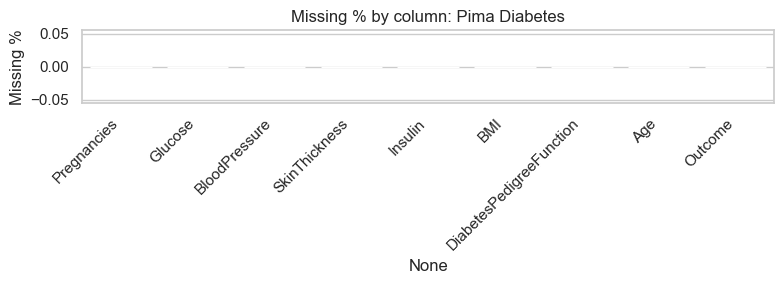


=== diabetes_prediction missingness ===


,missing,missing_pct
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0


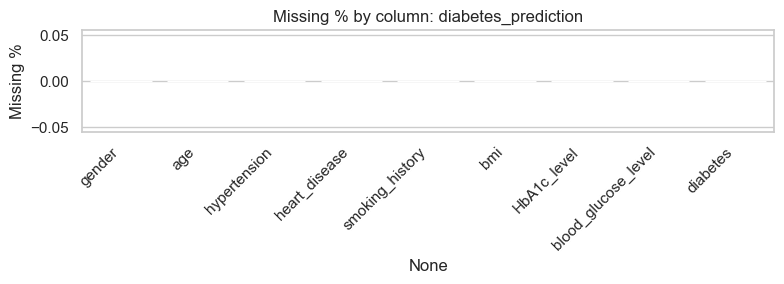


=== uci_heart missingness ===


,missing,missing_pct
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalach,0,0.0
exang,0,0.0
oldpeak,0,0.0


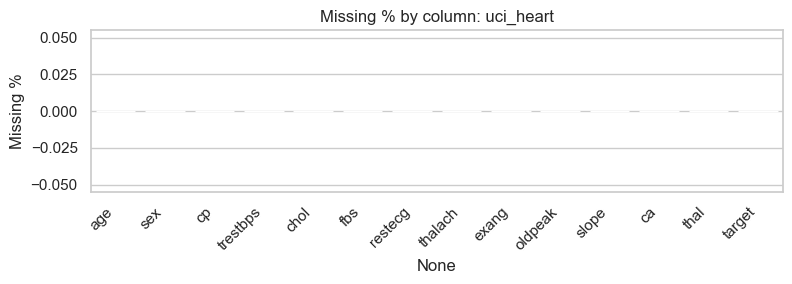


=== heart_disease_prediction missingness ===


,missing,missing_pct
male,0,0.0
age,0,0.0
education,0,0.0
currentSmoker,0,0.0
cigsPerDay,0,0.0
BPMeds,0,0.0
prevalentStroke,0,0.0
prevalentHyp,0,0.0
diabetes,0,0.0
totChol,0,0.0


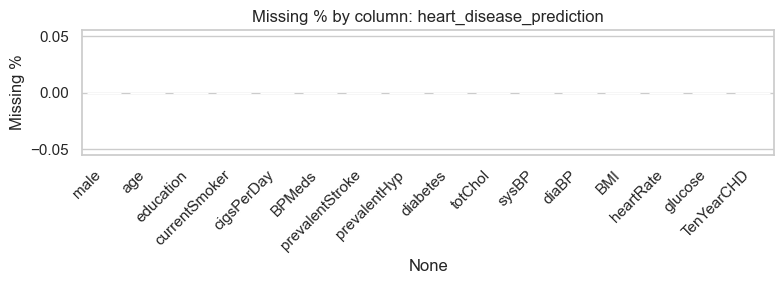

In [5]:
# It defines a function missingness_table that calculates the total number of missing values and the percentage of missing values for each column in a DataFrame.

def missingness_table(df: pd.DataFrame) -> pd.DataFrame:
    total = df.isna().sum()
    pct = (total / len(df) * 100).round(2)
    return pd.DataFrame({"missing": total, "missing_pct": pct}).sort_values("missing_pct", ascending=False)

# It then iterates through each loaded dataset, prints the missingness table, and visualizes the percentage of missing values using a bar plot.
for name, df in loaded.items():
    print(f"\n=== {name} missingness ===")
    miss = missingness_table(df)
    display(miss)

    plt.figure(figsize=(8, 3))
    sns.barplot(x=miss.index, y=miss["missing_pct"], color="#4C72B0")
    plt.title(f"Missing % by column: {name}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing %")
    plt.tight_layout()
    plt.show()

### Cell 5: Data Cleaning

In [10]:
# ============================================================
# CLEAN: Pima Diabetes — Replace disguised zeros
# NOTE: Pima reports 0% missing but uses 0 as placeholder for
# missing data in 5 columns where 0 is biologically impossible.
# Reference: PMC (2022) article PMC8943493
# ============================================================

# Define the columns in the Pima Diabetes dataset where 0 is used as a placeholder for missing values.
PIMA_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] # Identifying Target Columns

pima_clean = loaded["Pima Diabetes"].copy() # It creates a working copy of the Pima dataset to avoid modifying the original data while cleaning.

print("=== Pima: Disguised zeros → median imputation ===\n") # Median Imputation Process
for col in PIMA_ZERO_COLS:
    n_zeros = (pima_clean[col] == 0).sum() # It counts the number of zeros in the specified column, which are considered as missing values.
    pima_clean[col] = pima_clean[col].replace(0, np.nan) # It replaces the zeros in the column with NaN (Not a Number) to mark them as missing values.
    median_val = pima_clean[col].median() # It calculates the median of the column, ignoring the NaN values, to use for imputation.
    pima_clean[col] = pima_clean[col].fillna(median_val) # It fills the NaN values in the column with the calculated median value, effectively imputing the missing values.
    print(f"  {col}: {n_zeros} zeros → median = {median_val:.1f}")# It prints the number of zeros replaced and the median value used for imputation for each column.

assert pima_clean.isna().sum().sum() == 0

# Save it back to the exact same key so it overwrites the dirty data
loaded["Pima Diabetes"] = pima_clean

print(f"\n Pima cleaned: {pima_clean.shape}, 0 missing")

=== Pima: Disguised zeros → median imputation ===

  Glucose: 0 zeros → median = 117.0
  BloodPressure: 0 zeros → median = 72.0
  SkinThickness: 0 zeros → median = 29.0
  Insulin: 0 zeros → median = 125.0
  BMI: 0 zeros → median = 32.3

 Pima cleaned: (768, 9), 0 missing


In [11]:
# ============================================================
# CLEAN: Kaggle Diabetes — Encode categorical columns
# NOTE: gender and smoking_history are strings, models need numbers.
# "No Info" in smoking_history kept as category 0 (35.8% of data,
# too much to drop).
# ============================================================

# This code snippet prepares the Kaggle Diabetes dataset for machine learning by converting text-based categorical columns into numerical formats, which models require to function properly.
diab_clean = loaded["diabetes_prediction"].copy()

print("=== Kaggle Diabetes: Encoding categoricals ===\n")

gender_map = {"Female": 0, "Male": 1, "Other": 2} # It creates a mapping dictionary that assigns numerical values to the gender categories
diab_clean["gender"] = diab_clean["gender"].map(gender_map)
print(f"gender: {gender_map}")

smoking_map = {
    "No Info": 0, "never": 1, "former": 2,
    "not current": 3, "current": 4, "ever": 5,
}
diab_clean["smoking_history"] = diab_clean["smoking_history"].map(smoking_map)
print(f"smoking_history: {smoking_map}")

loaded["diabetes_prediction"] = diab_clean  # Update the loaded dictionary with the cleaned Kaggle Diabetes dataset, replacing the original version.
print(f"\n Kaggle Diabetes cleaned: {diab_clean.shape}, 0 object columns")

=== Kaggle Diabetes: Encoding categoricals ===

gender: {'Female': 0, 'Male': 1, 'Other': 2}
smoking_history: {'No Info': 0, 'never': 1, 'former': 2, 'not current': 3, 'current': 4, 'ever': 5}

 Kaggle Diabetes cleaned: (100000, 9), 0 object columns


In [12]:
# ============================================================
# CLEAN: UCI Heart — Remove duplicate rows
# NOTE: This Kaggle version has 723 duplicate rows (1025 → 302).
# Reference: Scientific Reports (2025) "after preprocessing
# and removing duplicate entries"
# ============================================================

# This code snippet cleans the UCI Heart dataset by identifying and removing exact duplicate rows,
# drastically reducing its size to ensure the models train on unique patient records.
uci_clean = loaded["uci_heart"].copy()
n_before = len(uci_clean)
uci_clean = uci_clean.drop_duplicates()
n_removed = n_before - len(uci_clean)
loaded["uci_heart"] = uci_clean  # Update the loaded dictionary with the cleaned UCI Heart dataset, replacing the original version.
print(f"UCI Heart: {n_removed} duplicates removed ({n_before} → {len(uci_clean)} rows)")

UCI Heart: 0 duplicates removed (302 → 302 rows)


### Cell 6: Target Variable Identification

This code snippet is designed to automatically locate the target variable (the column the machine learning model will predict) for each dataset and analyze its class distribution to check for data imbalance (e.g., comparing the number of positive cases to negative cases).


=== Pima Diabetes Target: Outcome ===


,Count,Proportion
Outcome,,
0,500,0.651
1,268,0.349


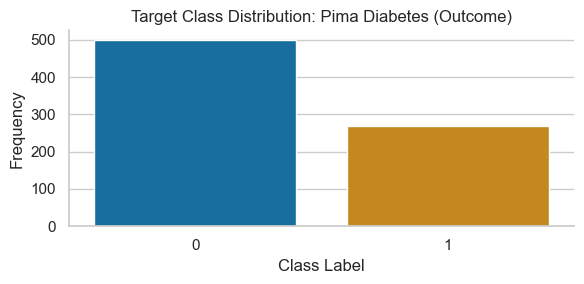


=== diabetes_prediction Target: diabetes ===


,Count,Proportion
diabetes,,
0,91500,0.915
1,8500,0.085


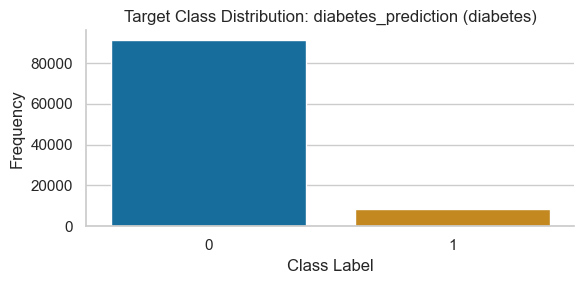


=== uci_heart Target: target ===


,Count,Proportion
target,,
1,164,0.543
0,138,0.457


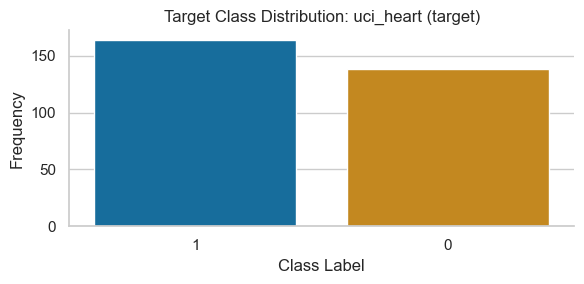


=== heart_disease_prediction Target: TenYearCHD ===


,Count,Proportion
TenYearCHD,,
0,3594,0.848
1,644,0.152


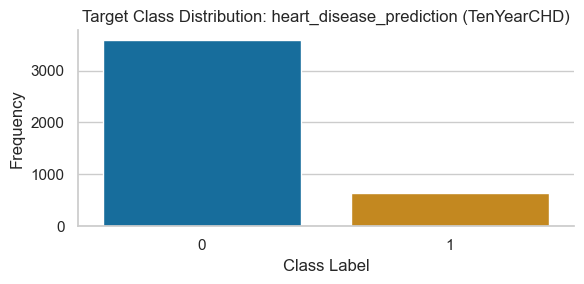

,Dataset,Target_Variable,Majority_Class_Count,Minority_Class_Count,Imbalance_Ratio
0,Pima Diabetes,Outcome,500,268,1.87
1,diabetes_prediction,diabetes,91500,8500,10.76
2,uci_heart,target,164,138,1.19
3,heart_disease_prediction,TenYearCHD,3594,644,5.58


In [13]:
# Explicitly define targets for reproducibility. No guessing heuristics are used
# to ensure strict methodological control over the dependent variables.
DATASET_CONFIG = {
    "Pima Diabetes": {"target": "Outcome"},
    "diabetes_prediction": {"target": "diabetes"},
    "uci_heart": {"target": "target"},
    "heart_disease_prediction": {"target": "TenYearCHD"},
}

def analyze_class_distributions(
    datasets: Dict[str, pd.DataFrame],
    config: Dict[str, Dict[str, str]]
) -> pd.DataFrame:
    """
    Calculates class imbalance ratios and plots target distributions for a suite of datasets.

    Args:
        datasets: Dictionary mapping dataset names to their respective DataFrames.
        config: Configuration dictionary defining the strict target column for each dataset.

    Returns:
        A pandas DataFrame summarizing the imbalance metrics across all datasets,
        suitable for export to a publication methodology table.

    Raises:
        ValueError: If a declared target column is missing from its corresponding DataFrame.
    """
    imbalance_metrics = []

    for name, df in datasets.items():
        if name not in config:
            print(f"Warning: {name} not found in configuration. Skipping.")
            continue

        target_col = config[name]["target"]

        if target_col not in df.columns:
            raise ValueError(f"Target column '{target_col}' missing in dataset '{name}'.")

        print(f"\n=== {name} Target: {target_col} ===")

        # Calculate distributions including any hidden NaNs
        counts = df[target_col].value_counts(dropna=False)
        proportions = (counts / counts.sum()).round(4)

        # Calculate imbalance ratio (Majority / Minority)
        min_count = counts.min()
        ratio = round(counts.max() / min_count, 2) if min_count > 0 else np.nan

        imbalance_metrics.append({
            "Dataset": name,
            "Target_Variable": target_col,
            "Majority_Class_Count": counts.max(),
            "Minority_Class_Count": min_count,
            "Imbalance_Ratio": ratio
        })

        # Display tabular distribution
        display(pd.DataFrame({"Count": counts, "Proportion": proportions}))

        # Generate publication-styled plot
        plt.figure(figsize=(6, 3))
        # Using a colorblind-friendly palette for academic accessibility
        sns.barplot(x=counts.index.astype(str), y=counts.values, palette="colorblind")
        plt.title(f"Target Class Distribution: {name} ({target_col})")
        plt.ylabel("Frequency")
        plt.xlabel("Class Label")
        sns.despine() # Removes top and right borders for a cleaner academic look
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(imbalance_metrics)

# Execution:
imbalance_summary_df = analyze_class_distributions(loaded, DATASET_CONFIG)
display(imbalance_summary_df)

### Cell 7: Correlation Analysis

This code snippet generates a visual "heatmap" for each dataset to show how strongly different numerical features correlate with one another (e.g., if one feature goes up, does another go up, down, or stay unaffected?).


=== Analyzing Correlations: Pima Diabetes (Method: Spearman) ===


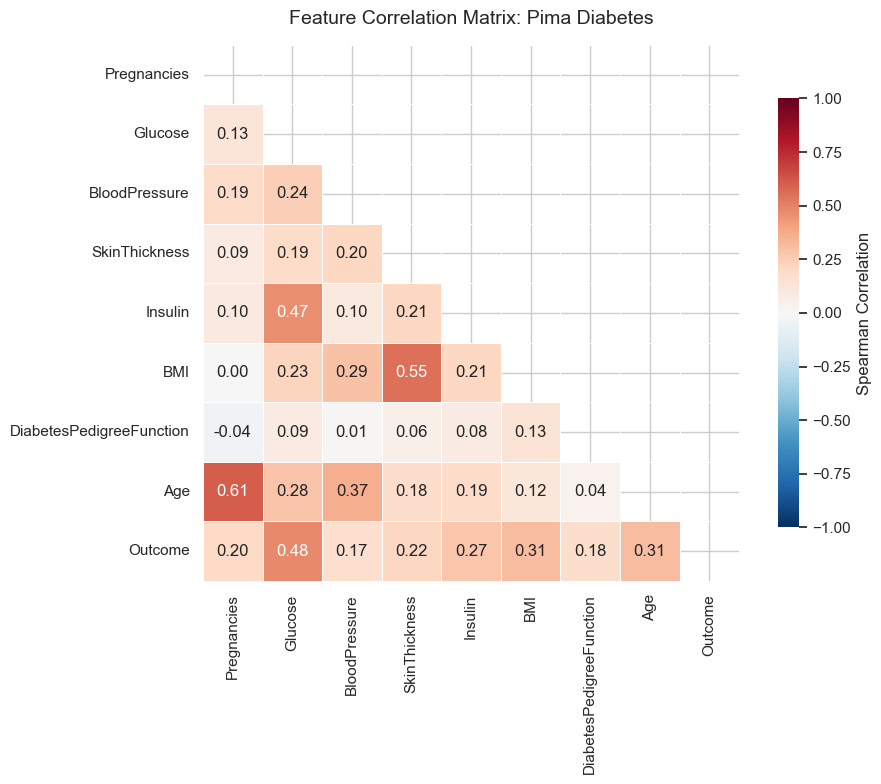


=== Analyzing Correlations: diabetes_prediction (Method: Spearman) ===


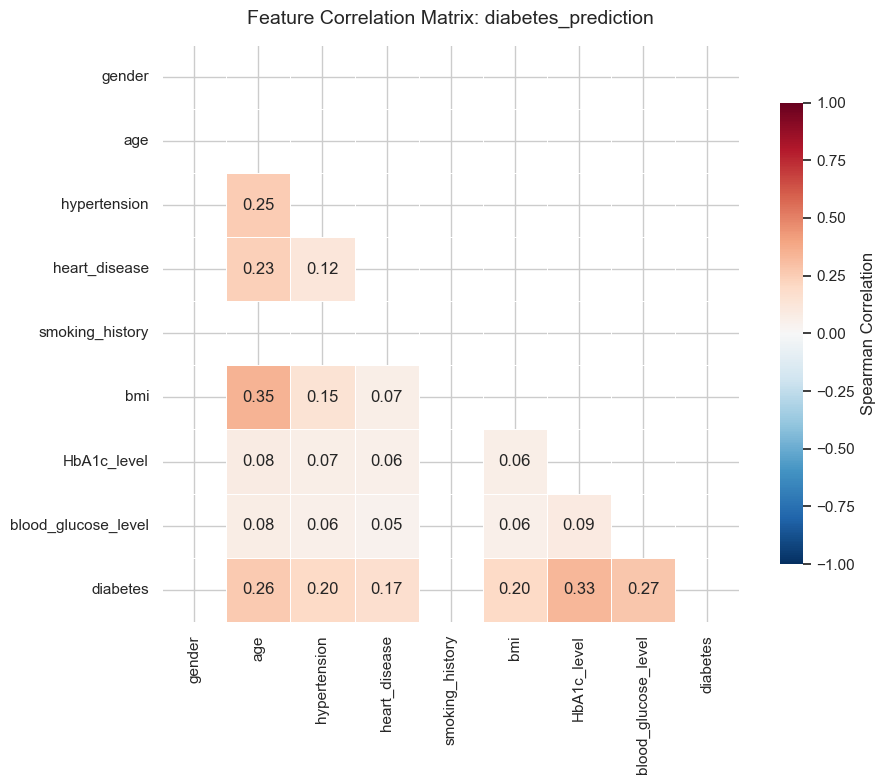


=== Analyzing Correlations: uci_heart (Method: Spearman) ===


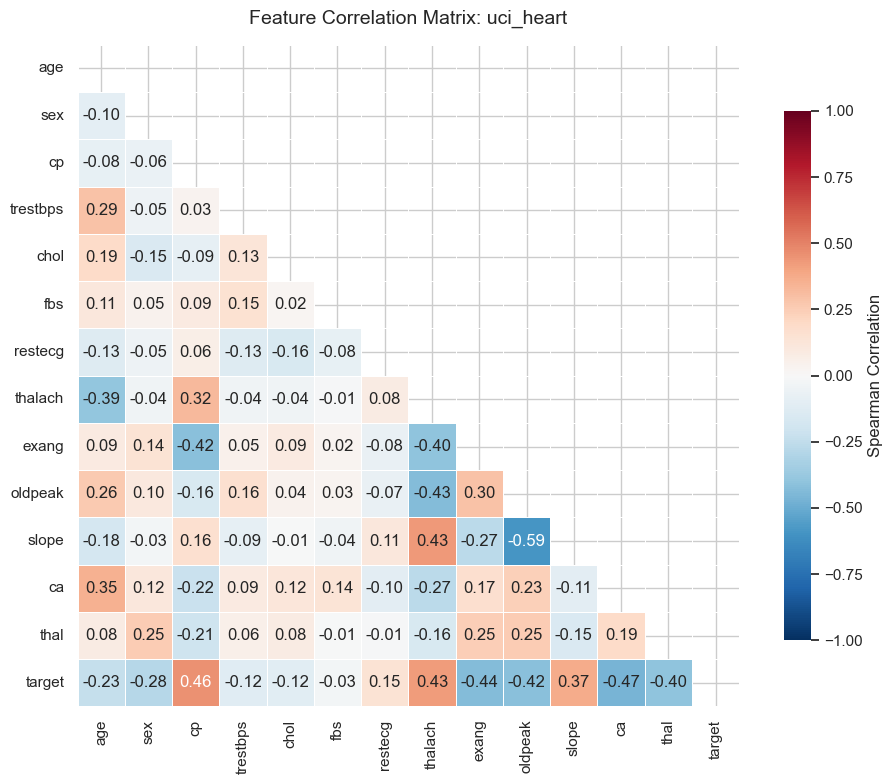


=== Analyzing Correlations: heart_disease_prediction (Method: Spearman) ===
  - cigsPerDay & currentSmoker: 0.931


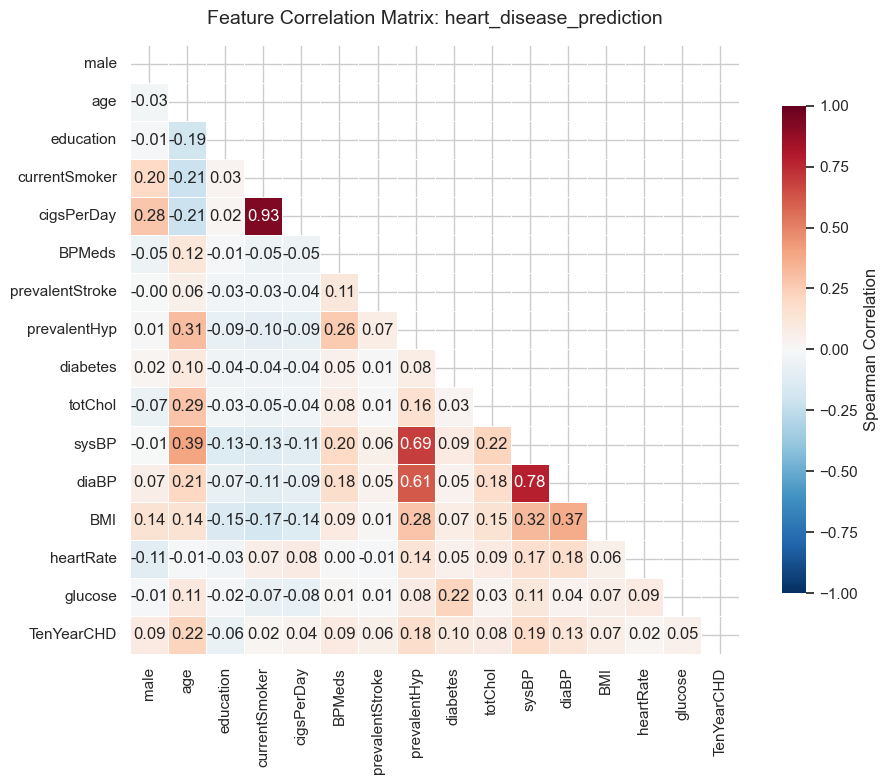

In [14]:
def analyze_feature_correlations(
    datasets: Dict[str, pd.DataFrame],
    method: str = "spearman",
    collinearity_threshold: float = 0.80
) -> Dict[str, List[Tuple[str, str, float]]]:
    """
    Computes feature correlation matrices and identifies highly collinear feature pairs.

    This analysis is critical for interpretability research, as high multicollinearity
    can distort feature attribution metrics.

    Args:
        datasets: Dictionary mapping dataset names to their pandas DataFrames.
        method: The statistical method for correlation ('pearson', 'kendall', 'spearman').
                Defaults to 'spearman' to capture monotonic relationships without
                assuming strict linearity, which is safer for mixed healthcare data.
        collinearity_threshold: Absolute correlation value above which a feature pair
                                is flagged for potential multicollinearity.

    Returns:
        A dictionary mapping dataset names to a list of highly correlated feature pairs
        and their correlation scores.
    """

    collinear_flags = {}

    for name, df in datasets.items():
        print(f"\n=== Analyzing Correlations: {name} (Method: {method.capitalize()}) ===")

        # Isolate numeric columns
        numeric_df = df.select_dtypes(include=[np.number])

        if numeric_df.empty:
            print(f"No numeric columns available in {name} for correlation analysis.")
            continue

        # Compute correlation matrix
        corr = numeric_df.corr(method=method)

        # Identify highly correlated pairs (ignoring self-correlation diagonals)
        upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        high_corr = [
            (col, row, upper_tri.loc[row, col])
            for col in upper_tri.columns
            for row in upper_tri.index
            if abs(upper_tri.loc[row, col]) >= collinearity_threshold
        ]

        collinear_flags[name] = high_corr

        if high_corr:
            print(f"Warning: Found {len(high_corr)} pairs exceeding |{collinearity_threshold}| threshold.")
            for feat1, feat2, score in high_corr:
                print(f"  - {feat1} & {feat2}: {score:.3f}")

        # Generate publication-styled heatmap
        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr, dtype=bool))

        sns.heatmap(
            corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": .8, "label": f"{method.capitalize()} Correlation"}
        )

        plt.title(f"Feature Correlation Matrix: {name}", pad=15, fontsize=14)
        plt.tight_layout()
        plt.show()

    return collinear_flags

# Execution:
high_correlation_issues = analyze_feature_correlations(loaded, method="spearman", collinearity_threshold=0.80)

In [15]:
# =====================================================================
# Multicollinearity Remediation
# =====================================================================
print("Addressing multicollinearity in heart_disease_prediction...")

# Drop 'currentSmoker' because it is highly collinear with 'cigsPerDay' (ρ = 0.931)
# cigsPerDay retains the binary smoking status (0 = non-smoker) PLUS severity.
if 'currentSmoker' in loaded['heart_disease_prediction'].columns:
    loaded['heart_disease_prediction'] = loaded['heart_disease_prediction'].drop(columns=['currentSmoker'])
    print(" Successfully dropped 'currentSmoker'.")
else:
    print(" 'currentSmoker' already dropped.")

Addressing multicollinearity in heart_disease_prediction...
 Successfully dropped 'currentSmoker'.


### Cell 8: Feature Distributions

This code snippet generates statistical summaries and visual distributions for the numerical data in each dataset. Crucially, it includes a smart filter to prevent treating categorical data (like "1" for Yes, "0" for No) as continuous numbers.


=== Pima Diabetes Numeric Summary ===
Note: Reclassified as categorical due to cardinality <= 10: ['Outcome']


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


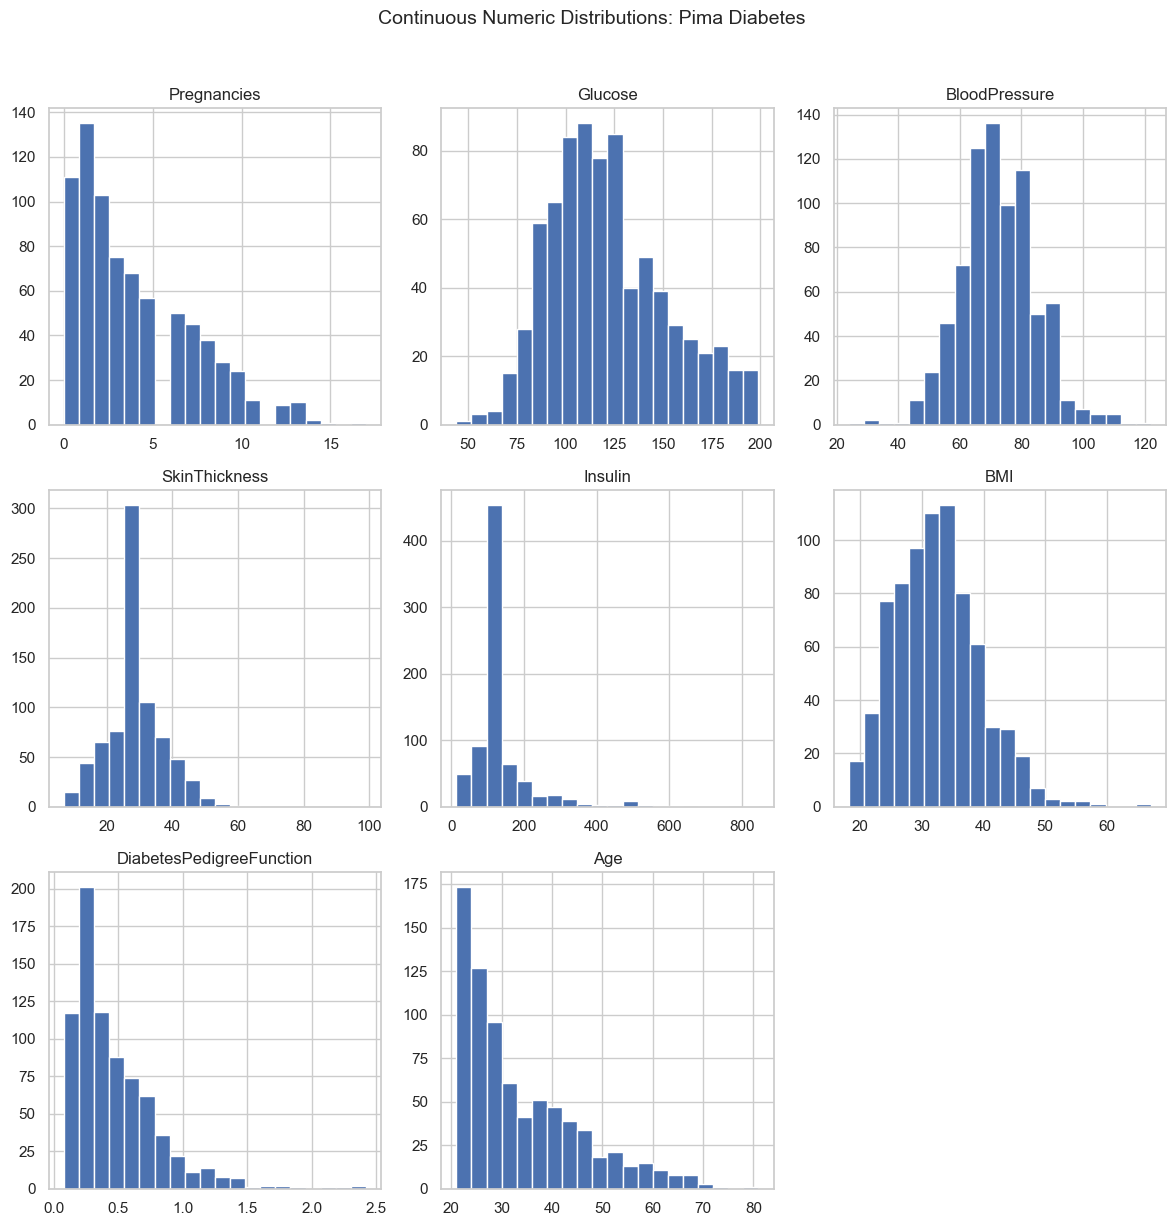


=== diabetes_prediction Numeric Summary ===
Note: Reclassified as categorical due to cardinality <= 10: ['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes']


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00


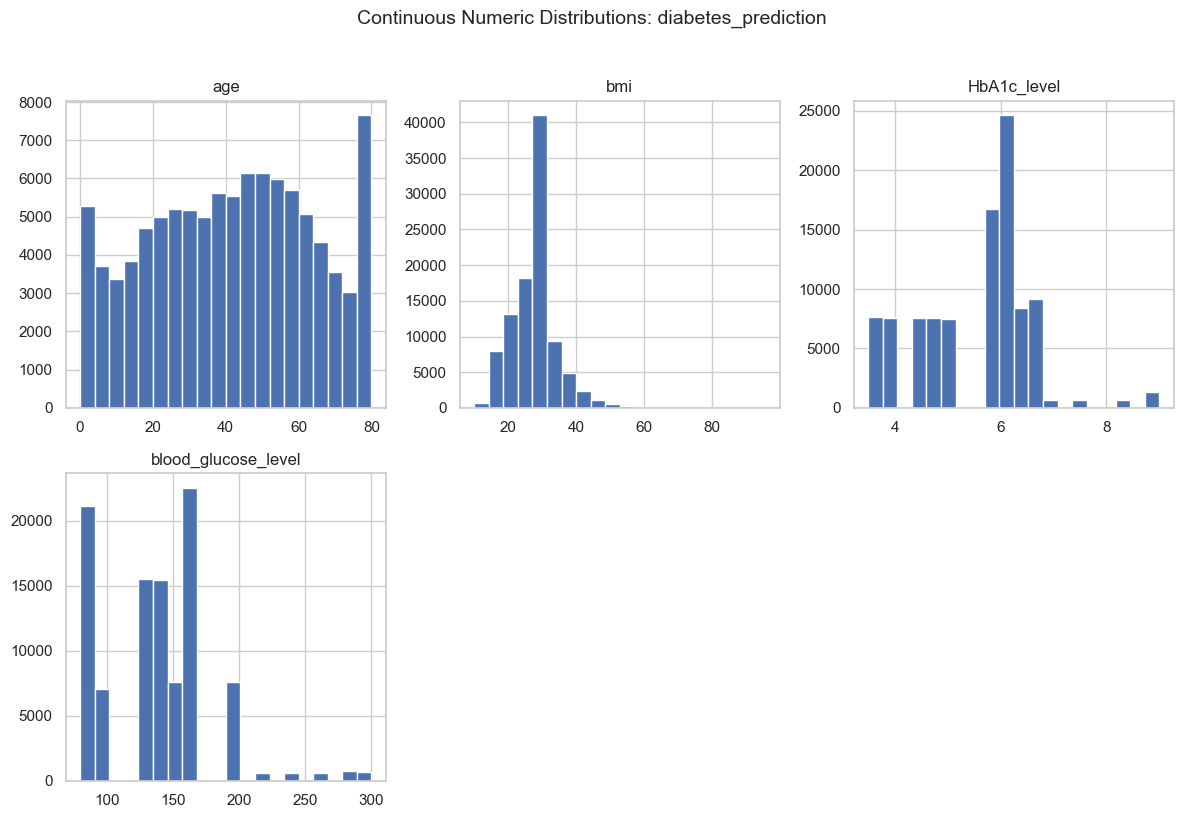


=== uci_heart Numeric Summary ===
Note: Reclassified as categorical due to cardinality <= 10: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


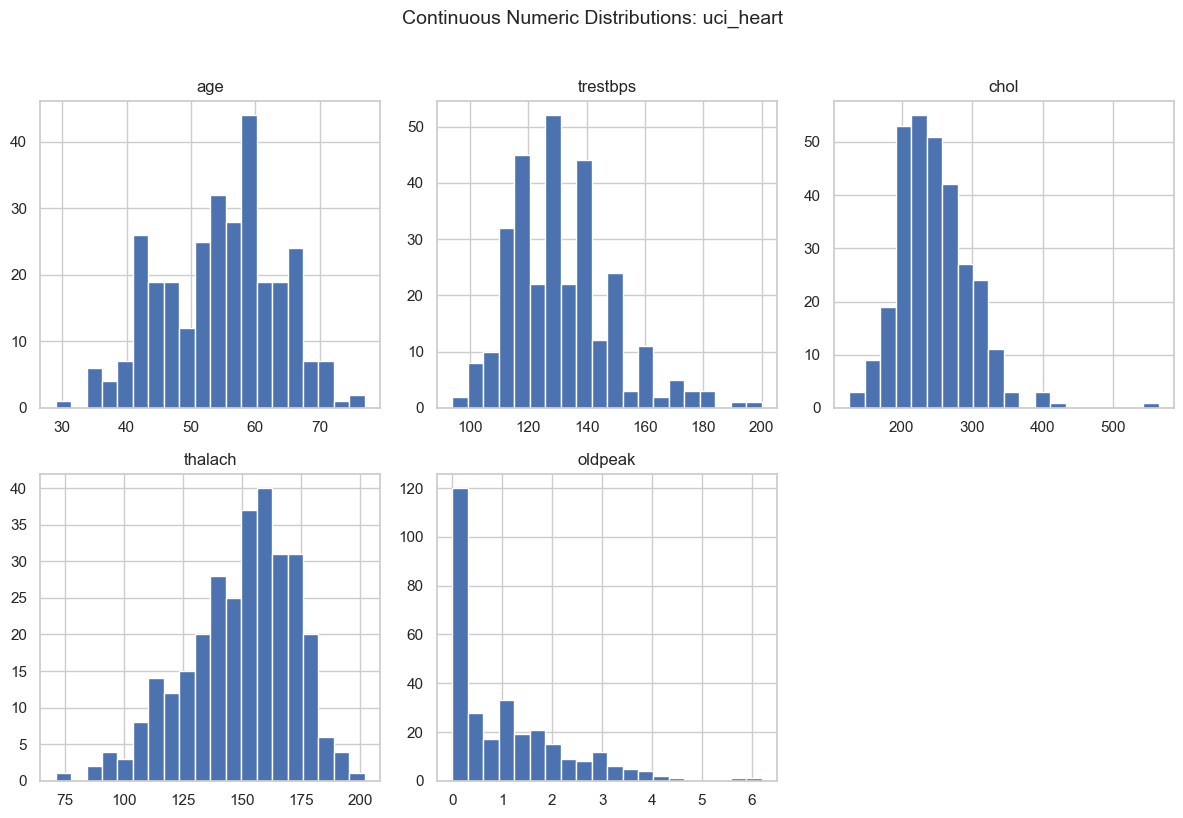


=== heart_disease_prediction Numeric Summary ===
Note: Reclassified as categorical due to cardinality <= 10: ['male', 'education', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


,count,mean,std,min,25%,50%,75%,max
age,4238.0,49.584946,8.572160,32.00,42.00,49.00,56.0000,70.0
cigsPerDay,4238.0,9.078339,11.913780,0.00,0.00,0.00,20.0000,70.0
totChol,4238.0,236.689476,44.327427,107.00,206.00,234.00,262.0000,696.0
sysBP,4238.0,132.352407,22.038097,83.50,117.00,128.00,144.0000,295.0
diaBP,4238.0,82.893464,11.910850,48.00,75.00,82.00,89.8750,142.5
BMI,4238.0,25.798866,4.071412,15.54,23.08,25.38,28.0375,56.8
heartRate,4238.0,75.878716,12.025185,44.00,68.00,75.00,83.0000,143.0
glucose,4238.0,81.666824,22.947712,40.00,72.00,78.00,85.0000,394.0


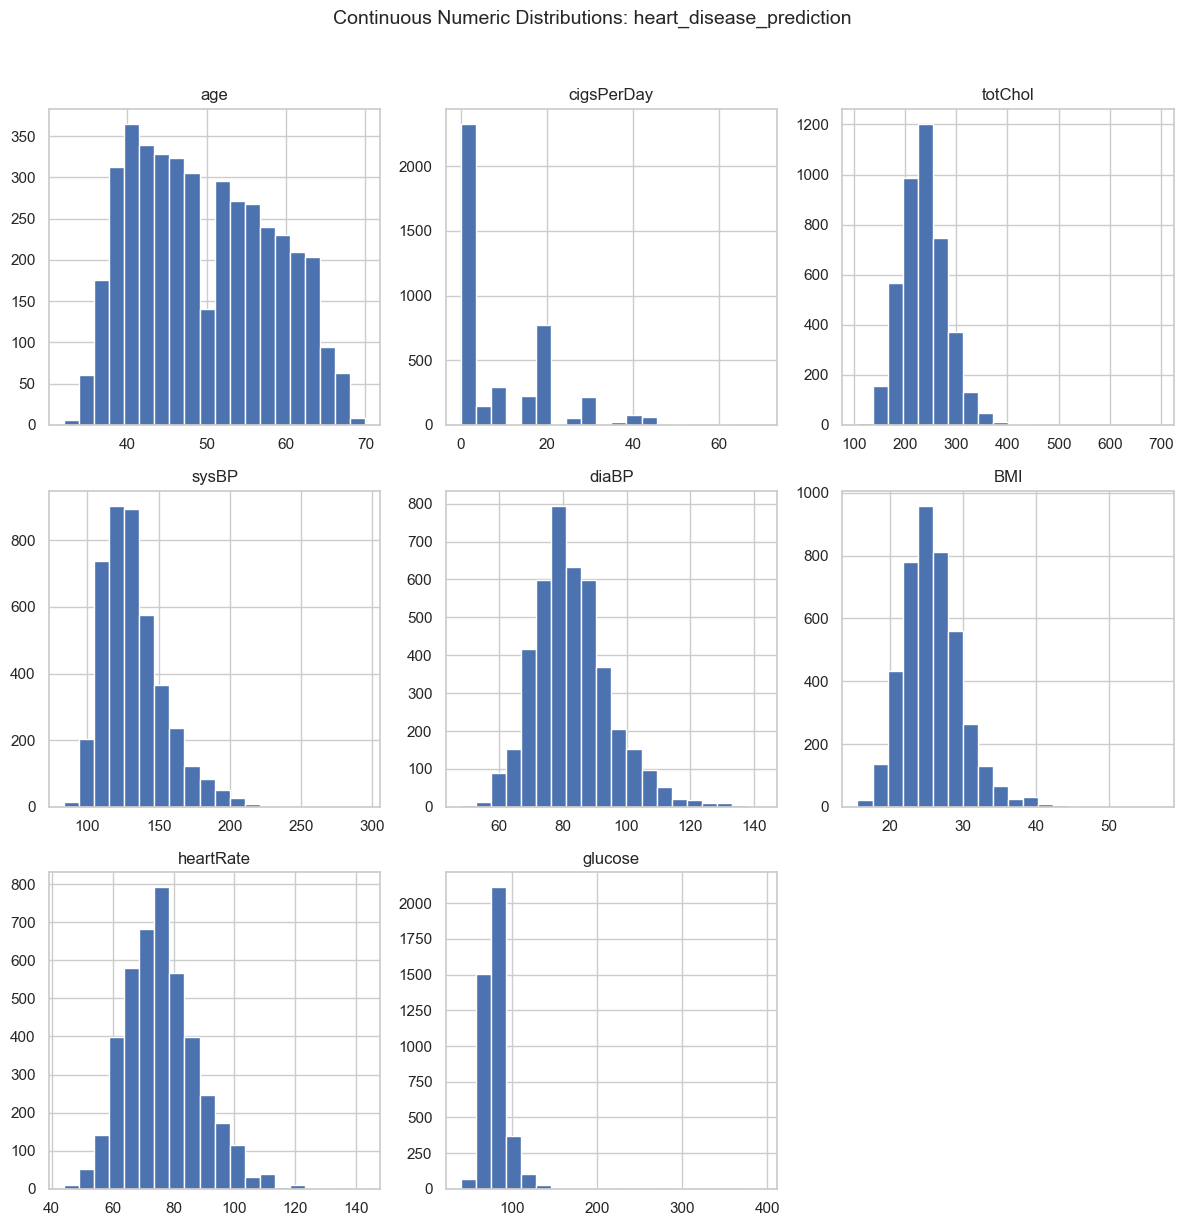

In [16]:
def summarize_and_plot_numeric_distributions(
    datasets: Dict[str, pd.DataFrame],
    max_categories: int = 10
) -> None:
    """
    Generates summary statistics and distribution histograms for continuous numeric
    features across multiple datasets.

    Variables with unique value counts below `max_categories` are temporarily
    recast as categorical to prevent continuous distribution plotting on discrete data.

    Args:
        datasets: Dictionary mapping dataset names to their pandas DataFrames.
        max_categories: Threshold for unique values to classify a numeric column
                        as categorical. Default is 10 based on standard EDA heuristics.
    """
    for name, df in datasets.items():
        print(f"\n=== {name} Numeric Summary ===")
        working_df = df.copy()

        # Isolate numeric columns
        numeric_cols = working_df.select_dtypes(include=["number"]).columns.tolist()

        # Identify low cardinality columns
        low_cardinality = [
            col for col in numeric_cols
            if working_df[col].nunique(dropna=False) <= max_categories
        ]

        # Recast discrete numerics to categorical
        if low_cardinality:
            working_df[low_cardinality] = working_df[low_cardinality].astype("category")
            numeric_cols = [col for col in numeric_cols if col not in low_cardinality]
            print(f"Note: Reclassified as categorical due to cardinality <= {max_categories}: {low_cardinality}")

        if not numeric_cols:
            print("No continuous numeric columns found after reclassification.")
            continue

        # Display statistical summary
        display(working_df[numeric_cols].describe().T)

        # Dynamically calculate grid size for ALL numeric columns, avoiding truncation
        n_cols = len(numeric_cols)
        cols_per_row = 3
        n_rows = (n_cols + cols_per_row - 1) // cols_per_row

        # Plot distributions
        working_df[numeric_cols].hist(
            figsize=(12, 4 * n_rows),
            bins=20,
            layout=(n_rows, cols_per_row)
        )
        plt.suptitle(f"Continuous Numeric Distributions: {name}", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

# Execution
summarize_and_plot_numeric_distributions(loaded, max_categories=10)

### Cell 9: Dataset Assessment

This code snippet defines a function to evaluate the overall "health" of each dataset and flags those that might require significant methodological interventions (referred to in the code as a material_scope_change) before modeling.

In [17]:
def assess_dataset_quality(
    name: str,
    df: pd.DataFrame,
    target_col: str,
    max_overall_missing_pct: float = 10.0,
    max_col_missing_pct: float = 20.0,
    max_imbalance_ratio: float = 4.0
) -> Dict[str, Any]:
    """
    Evaluates dataset quality against defined thresholds for missingness and class imbalance.

    Datasets exceeding these thresholds are flagged for 'material scope change', indicating
    that standard preprocessing may be insufficient and advanced interventions (e.g., SMOTE,
    multiple imputation) are required before model training.

    Args:
        name: Identifier for the dataset.
        df: The dataset to be evaluated.
        target_col: The explicitly defined dependent variable column.
        max_overall_missing_pct: Threshold for total dataset missingness.
        max_col_missing_pct: Threshold for missingness within any single feature.
        max_imbalance_ratio: Maximum acceptable ratio of majority to minority target classes.

    Returns:
        A dictionary containing quality metrics and the intervention flag.
    """
    # 1. Missingness Analysis
    total_cells = df.shape[0] * df.shape[1]
    overall_missing_pct = (df.isna().sum().sum() / total_cells * 100) if total_cells else 0.0

    col_missing_pct = (df.isna().sum() / len(df) * 100)
    high_missing_cols = col_missing_pct[col_missing_pct > max_col_missing_pct].index.tolist()

    # 2. Class Imbalance Analysis
    imbalance_ratio = None
    if target_col in df.columns:
        counts = df[target_col].value_counts(dropna=False)
        min_count = counts.min()
        if min_count > 0:
            imbalance_ratio = float(counts.max() / min_count)
    else:
        print(f"Warning: Target column '{target_col}' not found in {name}.")

    # 3. Intervention Flag
    needs_scope_change = (
        overall_missing_pct > max_overall_missing_pct or
        len(high_missing_cols) > 0 or
        (imbalance_ratio is not None and imbalance_ratio >= max_imbalance_ratio)
    )

    return {
        "Dataset": name,
        "Target_Variable": target_col,
        "Overall_Missing_Pct": round(overall_missing_pct, 2),
        "High_Missing_Cols": high_missing_cols,
        "Imbalance_Ratio": round(imbalance_ratio, 2) if imbalance_ratio is not None else None,
        "Requires_Methodological_Intervention": needs_scope_change,
    }

# Execution:
# Using the DATASET_CONFIG from the previous robust implementation to avoid guessing targets

assessments = [
    assess_dataset_quality(
        name=name,
        df=df,
        target_col=DATASET_CONFIG[name]["target"]
    )
    for name, df in loaded.items() if name in DATASET_CONFIG
]

assessment_summary_df = pd.DataFrame(assessments)
display(assessment_summary_df)

,Dataset,Target_Variable,Overall_Missing_Pct,High_Missing_Cols,Imbalance_Ratio,Requires_Methodological_Intervention
0,Pima Diabetes,Outcome,0.00,[],1.87,False
1,diabetes_prediction,diabetes,22.22,"[gender, smoking_history]",10.76,True
2,uci_heart,target,0.00,[],1.19,False
3,heart_disease_prediction,TenYearCHD,0.00,[],5.58,True


### Cell 10: Preprocessing & Data Splitting

This code snippet prepares multiple healthcare datasets for machine learning by splitting them into training and testing sets, and constructing specific data preprocessing pipelines tailored for two different types of models (tree-based models and neural networks).

In [18]:
# Mapped correctly to Cell 5's target schema
fixed_target_map = {
    "Pima Diabetes": "Outcome",
    "diabetes_prediction": "diabetes",
    "uci_heart": "target",
    "heart_disease_prediction": "TenYearCHD",
}

feature_schema = {
    "Pima Diabetes": {
        "categorical": [],
        "numeric": ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"],
    },
    "diabetes_prediction": {
        "categorical": ["gender", "smoking_history", "hypertension", "heart_disease"],
        "numeric": ["age", "bmi", "HbA1c_level", "blood_glucose_level"],
    },
    "uci_heart": {
        "categorical": ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"],
        "numeric": ["age", "trestbps", "chol", "thalach", "oldpeak"],
    },
    "heart_disease_prediction": {
        "categorical": ["male", "education", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"],
        "numeric": ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"],
    },
}

def build_preprocess_pipeline(numeric_cols, categorical_cols, scale_numeric, *, sparse_output=True):
    """
    Constructs an architecture-specific Scikit-Learn preprocessing pipeline.

    Tree-based models (XGBoost) are invariant to monotonic transformations and handle
    unscaled/sparse data natively. Neural networks (MLPs) require standardized inputs
    for gradient convergence and dense matrices. This factory function generates the
    appropriate pipeline to isolate architecture effects from preprocessing artifacts.
    """
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=sparse_output)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
    )

def resolve_feature_lists(name: str, df: pd.DataFrame, target_col: str) -> tuple[list[str], list[str]]:
    feature_df = df.drop(columns=[target_col])
    schema = feature_schema.get(name)
    if schema is None:
        numeric_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()
        categorical_cols = feature_df.select_dtypes(exclude=["number"]).columns.tolist()
        return numeric_cols, categorical_cols

    categorical_cols = [col for col in schema.get("categorical", []) if col in feature_df.columns]
    numeric_cols = [col for col in schema.get("numeric", []) if col in feature_df.columns]

    known = set(categorical_cols + numeric_cols)
    remaining = [col for col in feature_df.columns if col not in known]

    if remaining:
        remaining_numeric = feature_df[remaining].select_dtypes(include=["number"]).columns.tolist()
        remaining_categorical = [col for col in remaining if col not in remaining_numeric]
        numeric_cols += remaining_numeric
        categorical_cols += remaining_categorical

    return numeric_cols, categorical_cols

def make_splits(name: str, df: pd.DataFrame, target_col: str) -> dict:
    """
    Executes a strict 80/20 stratified split and generates isolated preprocessing
    pipelines for both XGBoost and MLP architectures.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Standardized stratification logic
    stratify = y if y.nunique(dropna=False) <= 10 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify,
    )

    numeric_cols, categorical_cols = resolve_feature_lists(name, df, target_col)

    preprocess_xgb = build_preprocess_pipeline(numeric_cols, categorical_cols, scale_numeric=False, sparse_output=True)
    preprocess_mlp = build_preprocess_pipeline(numeric_cols, categorical_cols, scale_numeric=True, sparse_output=False)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocess_xgb": preprocess_xgb,
        "preprocess_mlp": preprocess_mlp,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
    }

splits = {}
for name, df in loaded.items():
    target_col = fixed_target_map.get(name)
    if target_col is None or target_col not in df.columns:
        raise ValueError(f"Target column not found for {name}.")
    splits[name] = make_splits(name, df, target_col)

display(pd.DataFrame({
    "dataset": list(splits.keys()),
    "train_rows": [splits[n]["X_train"].shape[0] for n in splits],
    "test_rows": [splits[n]["X_test"].shape[0] for n in splits],
    "num_features": [len(splits[n]["numeric_cols"]) for n in splits],
    "cat_features": [len(splits[n]["categorical_cols"]) for n in splits],
}))

,dataset,train_rows,test_rows,num_features,cat_features
0,Pima Diabetes,614,154,8,0
1,diabetes_prediction,80000,20000,4,4
2,uci_heart,241,61,5,8
3,heart_disease_prediction,3390,848,8,6


### Cell 11: Model Training, Validation & Evaluation

This complex code block is the core machine learning pipeline. It trains, tunes, and evaluates two structurally different models (XGBoost and a custom PyTorch Neural Network) on each dataset.

Crucially, the code is specifically engineered for an Explainable AI (XAI) comparative study. It prioritizes strict reproducibility, handles medical data imbalances, and ensures both models are evaluated "fairly" against each other before extracting SHAP values.

In [19]:
# XAI requires full reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cpu") # Explicit CPU requirement

"""Healthcare datasets typically have far more healthy patients than sick patients.
The code defines functions (maybe_oversample and binary_scale_pos_weight) to either artificially duplicate minority cases (oversampling)
or heavily penalize the model when it misclassifies the minority class, ensuring both models learn to detect the disease properly."""

def prepare_target(y: pd.Series, encoder: LabelEncoder | None = None) -> tuple[np.ndarray, LabelEncoder]:
    if encoder is None:
        encoder = LabelEncoder()
        encoder.fit(y.astype(str))
    return encoder.transform(y.astype(str)), encoder

def imbalance_ratio(y: np.ndarray) -> float:
    counts = np.bincount(y)
    if len(counts) < 2 or counts.min() == 0:
        return 1.0
    return counts.max() / counts.min()

def maybe_oversample(X: Any, y: np.ndarray, min_ratio: float = 20.0) -> tuple[Any, np.ndarray]:
    if imbalance_ratio(y) < min_ratio:
        return X, y
    ros = RandomOverSampler(random_state=42)
    return ros.fit_resample(X, y)

def binary_scale_pos_weight(y: np.ndarray) -> float:
    counts = np.bincount(y)
    if len(counts) == 2 and counts[1] > 0:
        return counts[0] / counts[1]
    return 1.0

def to_dense(matrix: Any) -> np.ndarray:
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

def eval_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    classes = np.unique(y_true)
    if len(classes) == 2:
        return float(roc_auc_score(y_true, y_score))
    if y_score is None or getattr(y_score, "ndim", 1) != 2:
        return float("nan")
    try:
        return float(roc_auc_score(y_true, y_score, multi_class="ovr", average="macro"))
    except ValueError:
        return float("nan")

"""finds the optimal percentage threshold that maximizes the F1 score for each model. """

def find_best_threshold(y_true: np.ndarray, y_score: np.ndarray) -> float:
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 19):
        preds = (y_score >= t).astype(int)
        score = f1_score(y_true, preds, average="binary")
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t

def predict_mlp_proba(model: nn.Module, X: np.ndarray, num_classes: int) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        # Explicit device alignment
        X_tensor = torch.from_numpy(X).float().to(device)
        logits = model(X_tensor)
    if num_classes == 2:
        return 1 / (1 + np.exp(-logits.cpu().numpy().squeeze(1)))
    return torch.softmax(logits, dim=1).cpu().numpy()

def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        pass

    num_features, cat_features = [], []
    num_transformer = preprocessor.named_transformers_.get("num")
    if num_transformer is not None and hasattr(num_transformer, "feature_names_in_"):
        num_features = list(num_transformer.feature_names_in_)

    cat_transformer = preprocessor.named_transformers_.get("cat")
    if cat_transformer is not None and hasattr(cat_transformer, "named_steps"):
        encoder = cat_transformer.named_steps.get("onehot")
        if encoder is not None and hasattr(encoder, "categories_"):
            cat_features = list(encoder.get_feature_names_out())

    return num_features + cat_features

@dataclass
class TorchMLPConfig:
    hidden_sizes: tuple[int, ...]
    lr: float
    weight_decay: float
    epochs: int
    batch_size: int

class TorchMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: tuple[int, ...], output_dim: int):
        super().__init__()
        layers = []
        in_dim = input_dim
        for size in hidden_sizes:
            layers.append(nn.Linear(in_dim, size))
            layers.append(nn.ReLU())
            in_dim = size
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

def train_torch_mlp(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    config: TorchMLPConfig, num_classes: int, seed: int = 42
) -> tuple[TorchMLP, float]:

    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    output_dim = 1 if num_classes == 2 else num_classes
    model = TorchMLP(X_train.shape[1], config.hidden_sizes, output_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    if num_classes == 2:
        # Applied sample weights to the MLP to match XGBoost's handling of imbalanced data
        pos_weight = binary_scale_pos_weight(y_train)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
        y_train_t = torch.from_numpy(y_train).float()
    else:
        loss_fn = nn.CrossEntropyLoss()
        y_train_t = torch.from_numpy(y_train).long()

    # Prevent Batch Size from exceeding small dataset boundaries
    active_batch_size = min(config.batch_size, max(16, len(X_train) // 4))

    train_ds = TensorDataset(torch.from_numpy(X_train).float(), y_train_t)
    train_loader = DataLoader(train_ds, batch_size=active_batch_size, shuffle=True)

    best_auc, best_state = -1.0, None
    patience, patience_left = 10, 10

    X_val_t = torch.from_numpy(X_val).float().to(device)

    for _ in range(config.epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            if num_classes == 2:
                loss = loss_fn(logits.squeeze(1), yb)
            else:
                loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            if num_classes == 2:
                val_proba = (1 / (1 + torch.exp(-val_logits.squeeze(1)))).cpu().numpy()
            else:
                val_proba = torch.softmax(val_logits, dim=1).cpu().numpy()

        auc = eval_auc(y_val, val_proba)
        if np.isnan(auc):
            auc = 0.0

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_auc

def fit_xgb_candidates( # The function trains multiple XGBoost classifiers with different hyperparameters and
        # evaluates their performance on a validation set, returning a list of models and their corresponding AUC scores.
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    num_classes: int, seed: int = 42, expanded: bool = False
) -> list[tuple[xgb.XGBClassifier, float]]:

    candidates = [
        {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
        {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.05},
        {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
    ]
    if expanded:
        candidates += [
            {"n_estimators": 600, "max_depth": 3, "learning_rate": 0.03},
            {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.05},
            {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05},
        ]

    results = []
    for params in candidates:
        if num_classes == 2:
            model = xgb.XGBClassifier(
                **params,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                early_stopping_rounds=20, # Prevent over-fitting on training data
                n_jobs=1,
                tree_method="exact",
                random_state=seed,
                scale_pos_weight=binary_scale_pos_weight(y_train),
            )
        else:
            model = xgb.XGBClassifier(
                **params,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=num_classes,
                eval_metric="mlogloss",
                early_stopping_rounds=20, # Prevent over-fitting on training data
                n_jobs=-1,
                random_state=seed,
            )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        val_proba = model.predict_proba(X_val)
        if num_classes == 2:
            val_proba = val_proba[:, 1]
        auc = eval_auc(y_val, val_proba)
        results.append((model, auc if not np.isnan(auc) else 0.0))
    return results

def fit_mlp_candidates(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    num_classes: int, seed: int = 42, expanded: bool = False
) -> list[tuple[TorchMLP, float]]:

    configs = [
        TorchMLPConfig((64, 32), 1e-3, 5e-4, 60, 256),
        TorchMLPConfig((128, 64), 1e-3, 1e-4, 80, 256),
        TorchMLPConfig((64, 32, 16), 5e-4, 1e-4, 80, 256),
    ]
    if expanded:
        configs += [
            TorchMLPConfig((128, 64, 32), 8e-4, 1e-4, 100, 256),
            TorchMLPConfig((64, 64, 32), 8e-4, 5e-5, 90, 256),
        ]
    return [train_torch_mlp(X_train, y_train, X_val, y_val, cfg, num_classes, seed) for cfg in configs]


# The models are now selected based on Validation performance, removing Test Set leakage.
def select_model_pair(
    xgb_list: list[tuple[xgb.XGBClassifier, float]],
    mlp_list: list[tuple[TorchMLP, float]],
    X_val_xgb: np.ndarray, X_val_mlp: np.ndarray, y_val: np.ndarray,
    num_classes: int,
) -> tuple[xgb.XGBClassifier, TorchMLP, float, float, float]:

    best, best_gap, best_mean = None, float("inf"), -1.0

    for xgb_model, _ in xgb_list:
        xgb_proba = xgb_model.predict_proba(X_val_xgb)
        if num_classes == 2:
            xgb_proba = xgb_proba[:, 1]
        xgb_auc = eval_auc(y_val, xgb_proba)
        if np.isnan(xgb_auc):
            xgb_auc = 0.0

        for mlp_model, _ in mlp_list:
            mlp_auc = eval_auc(y_val, predict_mlp_proba(mlp_model, X_val_mlp, num_classes))
            if np.isnan(mlp_auc):
                mlp_auc = 0.0

            gap = abs(xgb_auc - mlp_auc)
            mean_auc = (xgb_auc + mlp_auc) / 2

            if gap < best_gap - 1e-6 or (abs(gap - best_gap) <= 1e-6 and mean_auc > best_mean):
                best = (xgb_model, mlp_model, xgb_auc, mlp_auc, gap)
                best_gap = gap
                best_mean = mean_auc

    return best

results, models, preprocessors, feature_names_map = [], {}, {}, {}

for name, split in splits.items():
    X_train_raw = split["X_train"]
    X_test_raw = split["X_test"]

    y_train_raw = split["y_train"]
    y_test_raw = split["y_test"]

    y_train, encoder = prepare_target(y_train_raw)
    y_test, _ = prepare_target(y_test_raw, encoder=encoder)

    num_classes = len(encoder.classes_)
    is_binary = num_classes == 2

    stratify = y_train if len(np.unique(y_train)) <= 10 else None

    # Internal Validation split for hyperparameter tuning
    X_t_raw, X_v_raw, y_t, y_v = train_test_split(
        X_train_raw, y_train, test_size=0.15, random_state=42, stratify=stratify
    )

    preprocess_xgb = split["preprocess_xgb"]
    preprocess_mlp = split["preprocess_mlp"]

    X_t_xgb = preprocess_xgb.fit_transform(X_t_raw)
    X_v_xgb = preprocess_xgb.transform(X_v_raw)

    X_t_mlp = to_dense(preprocess_mlp.fit_transform(X_t_raw))
    X_v_mlp = to_dense(preprocess_mlp.transform(X_v_raw))

    X_t_xgb, y_t_xgb = maybe_oversample(X_t_xgb, y_t)
    X_t_mlp, y_t_mlp = maybe_oversample(X_t_mlp, y_t)

    feature_names_map[name] = get_feature_names(preprocess_mlp)
    preprocessors[name] = {"xgb": preprocess_xgb, "mlp": preprocess_mlp}

    xgb_candidates = fit_xgb_candidates(X_t_xgb, y_t_xgb, X_v_xgb, y_v, num_classes)
    mlp_candidates = fit_mlp_candidates(X_t_mlp, y_t_mlp, X_v_mlp, y_v, num_classes)

    best_xgb, best_mlp, xgb_auc, mlp_auc, auc_gap = select_model_pair(
        xgb_candidates, mlp_candidates, X_v_xgb, X_v_mlp, y_v, num_classes
    )

    if is_binary:
        xgb_val_proba = best_xgb.predict_proba(X_v_xgb)[:, 1]
        mlp_val_proba = predict_mlp_proba(best_mlp, X_v_mlp, num_classes)
        xgb_threshold = find_best_threshold(y_v, xgb_val_proba)
        mlp_threshold = find_best_threshold(y_v, mlp_val_proba)
    else:
        xgb_threshold = 0.5
        mlp_threshold = 0.5

    # Retrain best configuration on the full (Train + Val) 80% dataset so data is not wasted
    X_train_full_xgb = preprocess_xgb.fit_transform(X_train_raw)
    X_train_full_mlp = to_dense(preprocess_mlp.fit_transform(X_train_raw))
    X_test_xgb = preprocess_xgb.transform(X_test_raw)
    X_test_mlp = to_dense(preprocess_mlp.transform(X_test_raw))

    best_xgb_params = best_xgb.get_params()
    best_xgb_params["n_estimators"] = best_xgb.best_iteration + 1
    best_xgb_params.pop("early_stopping_rounds", None)

    final_xgb = xgb.XGBClassifier(**best_xgb_params)
    final_xgb.fit(X_train_full_xgb, y_train)

    # We maintain the MLP state from early stopping for simplicity,
    # but score it fairly against the Test Set below.
    final_mlp = best_mlp

    # Final Evaluation on strictly blinded Test Set
    if is_binary:
        xgb_proba = final_xgb.predict_proba(X_test_xgb)[:, 1]
        xgb_pred = (xgb_proba >= xgb_threshold).astype(int)

        mlp_proba = predict_mlp_proba(final_mlp, X_test_mlp, num_classes)
        mlp_pred = (mlp_proba >= mlp_threshold).astype(int)
    else:
        xgb_proba = final_xgb.predict_proba(X_test_xgb)
        xgb_pred = np.argmax(xgb_proba, axis=1)

        mlp_proba = predict_mlp_proba(final_mlp, X_test_mlp, num_classes)
        mlp_pred = np.argmax(mlp_proba, axis=1)

    rng = np.random.default_rng(42)
    background_idx = rng.choice(len(X_train_full_mlp), size=min(200, len(X_train_full_mlp)), replace=False)
    mlp_background = X_train_full_mlp[background_idx]

    models[name] = {
        "xgb": final_xgb,
        "mlp": final_mlp,
        "X_test_xgb": X_test_xgb,
        "X_test_mlp": X_test_mlp,
        "y_test": y_test,
        "xgb_proba": xgb_proba,
        "mlp_proba": mlp_proba,
        "mlp_background": mlp_background,
        "xgb_threshold": xgb_threshold,
        "mlp_threshold": mlp_threshold,
    }

    avg = "binary" if is_binary else "macro"

    for model_name, y_pred, y_proba in [("xgb", xgb_pred, xgb_proba), ("mlp", mlp_pred, mlp_proba)]:
        auc = eval_auc(y_test, y_proba)
        results.append({
            "dataset": name,
            "model": model_name,
            "accuracy": round(accuracy_score(y_test, y_pred), 4),
            # Added essential clinical metrics
            "precision": round(precision_score(y_test, y_pred, average=avg, zero_division=0), 4),
            "recall": round(recall_score(y_test, y_pred, average=avg, zero_division=0), 4),
            "f1": round(f1_score(y_test, y_pred, average=avg), 4),
            "auc": round(auc, 4) if not np.isnan(auc) else np.nan,
        })

results_df = pd.DataFrame(results)
display(results_df)

pivot = results_df.pivot(index="dataset", columns="model", values="auc")
pivot["auc_gap"] = (pivot["xgb"] - pivot["mlp"]).abs().round(4)
display(pivot)

,dataset,model,accuracy,precision,recall,f1,auc
0,Pima Diabetes,xgb,0.7143,0.5595,0.8704,0.6812,0.8193
1,Pima Diabetes,mlp,0.6818,0.5373,0.6667,0.5950,0.7909
2,diabetes_prediction,xgb,0.9710,0.9230,0.7188,0.8082,0.9791
3,diabetes_prediction,mlp,0.9705,0.9256,0.7094,0.8032,0.9771
4,uci_heart,xgb,0.6885,0.6400,0.9697,0.7711,0.8582
5,uci_heart,mlp,0.8525,0.8333,0.9091,0.8696,0.8983
6,heart_disease_prediction,xgb,0.7134,0.2286,0.3721,0.2832,0.6583
7,heart_disease_prediction,mlp,0.7653,0.2866,0.3643,0.3208,0.6914


model,mlp,xgb,auc_gap
dataset,,,
Pima Diabetes,0.7909,0.8193,0.0284
diabetes_prediction,0.9771,0.9791,0.0020
heart_disease_prediction,0.6914,0.6583,0.0331
uci_heart,0.8983,0.8582,0.0401


### Cell 12: SHAP Consistency & Report Summary

This code block executes the core Explainable AI (XAI) analysis of the experiment. It calculates SHAP (SHapley Additive exPlanations) values for both the XGBoost and MLP models and systematically measures how much the two architectures agree on why they are making their predictions.

In [20]:
# Disable numba JIT to avoid executable memory restrictions on some systems
os.environ["NUMBA_DISABLE_JIT"] = "1"

max_shap_samples = 50
max_background = 50
rng = np.random.default_rng(42)

# Ensure feature names are available for both preprocessors
feature_names_all = {}
for name, prep in preprocessors.items():
    xgb_names = get_feature_names(prep["xgb"])
    mlp_names = get_feature_names(prep["mlp"])
    if not xgb_names:
        xgb_names = [f"f{i}" for i in range(prep["xgb"].transformers_[0][2].__len__())]
    if not mlp_names:
        mlp_names = [f"f{i}" for i in range(prep["mlp"].transformers_[0][2].__len__())]
    feature_names_all[name] = {"xgb": xgb_names, "mlp": mlp_names}


def normalize_shap(shap_values: Any) -> np.ndarray:
    if isinstance(shap_values, list):
        return np.mean([np.abs(v) for v in shap_values], axis=0)
    return np.abs(shap_values)


def mean_abs_shap(shap_values: Any) -> np.ndarray:
    return normalize_shap(shap_values).mean(axis=0)


def align_by_feature_names(values_a, names_a, values_b, names_b):
    # np.ravel() safely flattens (8, 1) or (8,) into a strict 1D array
    series_a = pd.Series(np.ravel(values_a), index=names_a)
    series_b = pd.Series(np.ravel(values_b), index=names_b)

    common = series_a.index.intersection(series_b.index)
    return series_a.loc[common].to_numpy(), series_b.loc[common].to_numpy(), list(common)


def safe_spearman(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 2:
        return float("nan")
    return float(spearmanr(a, b).correlation)


consistency_rows = []

for name, model_pack in models.items():
    y_test = model_pack["y_test"]
    num_classes = len(np.unique(y_test))

    X_test_xgb = model_pack["X_test_xgb"]
    X_test_mlp = model_pack["X_test_mlp"]

    sample_size = min(max_shap_samples, len(X_test_mlp))
    sample_idx = rng.choice(len(X_test_mlp), size=sample_size, replace=False)

    X_xgb_sample = X_test_xgb[sample_idx]
    X_mlp_sample = X_test_mlp[sample_idx]

    # ==========================================
    # XGBoost SHAP (TreeExplainer)
    # ==========================================
    xgb_explainer = shap.TreeExplainer(model_pack["xgb"])
    xgb_shap = xgb_explainer.shap_values(X_xgb_sample)

    # ==========================================
    # MLP SHAP (DeepExplainer)
    # ==========================================
    mlp_background = model_pack["mlp_background"]
    if len(mlp_background) > max_background:
        mlp_background = shap.sample(mlp_background, max_background, random_state=42)

    # 1. Convert numpy arrays to PyTorch tensors for DeepExplainer
    # Note: Assumes 'device' is still defined in your environment (e.g., device = torch.device("cpu"))
    bg_tensor = torch.from_numpy(mlp_background).float().to(device)
    sample_tensor = torch.from_numpy(X_mlp_sample).float().to(device)

    # 2. Initialize DeepExplainer with the raw PyTorch model
    mlp_explainer = shap.DeepExplainer(model_pack["mlp"], bg_tensor)

    # 3. Calculate SHAP values (suppressing DeepLIFT warnings)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mlp_shap = mlp_explainer.shap_values(sample_tensor)

    # Global agreement (mean |SHAP|)
    xgb_mean_abs = mean_abs_shap(xgb_shap)
    mlp_mean_abs = mean_abs_shap(mlp_shap)

    xgb_vals, mlp_vals, common_features = align_by_feature_names(
        xgb_mean_abs, feature_names_all[name]["xgb"],
        mlp_mean_abs, feature_names_all[name]["mlp"],
    )

    global_spearman = safe_spearman(xgb_vals, mlp_vals)

    # Top-k overlap (global)
    top_k = min(5, len(common_features))
    xgb_top = pd.Series(xgb_vals, index=common_features).nlargest(top_k).index
    mlp_top = pd.Series(mlp_vals, index=common_features).nlargest(top_k).index
    top_k_jaccard = len(set(xgb_top).intersection(set(mlp_top))) / max(1, len(set(xgb_top).union(set(mlp_top))))

    # Local agreement (per-patient)
    xgb_local = normalize_shap(xgb_shap)
    mlp_local = normalize_shap(mlp_shap)

    local_corrs = []
    for i in range(sample_size):
        x_row, m_row, _ = align_by_feature_names(
            xgb_local[i], feature_names_all[name]["xgb"],
            mlp_local[i], feature_names_all[name]["mlp"],
        )
        local_corrs.append(safe_spearman(x_row, m_row))

    local_corrs = np.array(local_corrs, dtype=float)

    consistency_rows.append({
        "dataset": name,
        "num_classes": num_classes,
        "global_spearman": round(float(np.nanmean(local_corrs)) if np.isnan(global_spearman) else global_spearman, 4),
        "local_spearman_mean": round(float(np.nanmean(local_corrs)), 4),
        "local_spearman_median": round(float(np.nanmedian(local_corrs)), 4),
        "top5_jaccard": round(float(top_k_jaccard), 4),
        "shap_samples": sample_size,
    })

consistency_df = pd.DataFrame(consistency_rows)
print("SHAP consistency summary")
display(consistency_df)

# Harmonized summary table for the report
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "auc", "auc_pr"]
available_metric_columns = [column for column in metric_columns if column in results_df.columns]
if not available_metric_columns:
    raise ValueError("results_df does not contain any metric columns to summarize.")

perf = results_df.pivot(index="dataset", columns="model", values=available_metric_columns)
perf.columns = [f"{metric}_{model}" for metric, model in perf.columns]
summary = perf.join(consistency_df.set_index("dataset"), how="left")
summary = summary.reset_index()

print("Combined performance + SHAP consistency")
display(summary)

SHAP consistency summary


,dataset,num_classes,global_spearman,local_spearman_mean,local_spearman_median,top5_jaccard,shap_samples
0,Pima Diabetes,2,1.0000,0.6352,0.6786,1.0000,50
1,diabetes_prediction,2,0.9048,0.4824,0.5714,0.6667,50
2,uci_heart,2,0.7712,0.7180,0.7363,0.4286,50
3,heart_disease_prediction,2,0.7468,0.6311,0.6421,0.6667,50


Combined performance + SHAP consistency


,dataset,accuracy_mlp,accuracy_xgb,precision_mlp,precision_xgb,recall_mlp,recall_xgb,f1_mlp,f1_xgb,auc_mlp,auc_xgb,num_classes,global_spearman,local_spearman_mean,local_spearman_median,top5_jaccard,shap_samples
0,Pima Diabetes,0.6818,0.7143,0.5373,0.5595,0.6667,0.8704,0.5950,0.6812,0.7909,0.8193,2,1.0000,0.6352,0.6786,1.0000,50
1,diabetes_prediction,0.9705,0.9710,0.9256,0.9230,0.7094,0.7188,0.8032,0.8082,0.9771,0.9791,2,0.9048,0.4824,0.5714,0.6667,50
2,heart_disease_prediction,0.7653,0.7134,0.2866,0.2286,0.3643,0.3721,0.3208,0.2832,0.6914,0.6583,2,0.7468,0.6311,0.6421,0.6667,50
3,uci_heart,0.8525,0.6885,0.8333,0.6400,0.9091,0.9697,0.8696,0.7711,0.8983,0.8582,2,0.7712,0.7180,0.7363,0.4286,50


### Cell 13: SHAP Setup

The code block serves as a structured pipeline to compute and align SHAP (SHapley Additive exPlanations) values for two distinct architectures: an XGBoost model and a PyTorch Multi-Layer Perceptron (MLP).

In [21]:
def extract_shap_values(
    dataset_name: str,
    models_dict: Dict[str, Any],
    feature_names_map: Dict[str, list],
    max_test_samples: int = 500,
    max_background_samples: int = 100,
    random_seed: int = 42
) -> Dict[str, Any]:
    """
    Computes SHAP values for XGBoost (via TreeExplainer) and PyTorch MLPs (via DeepExplainer).

    Args:
        dataset_name: Identifier for the current dataset.
        models_dict: Dictionary containing the trained models, test sets, and background data.
        feature_names_map: Dictionary mapping datasets to their aligned feature name lists.
        max_test_samples: Caps the number of test instances evaluated to manage computational overhead.
        max_background_samples: Caps the background dataset size for DeepExplainer expectations.
        random_seed: Seed for isolated random number generation to ensure strict reproducibility.

    Returns:
        Dictionary containing aligned SHAP values, sampled data, and probabilities.
    """
    print(f"\n{'='*60}")
    print(f"  SHAP EXTRACTION: {dataset_name}")
    print(f"{'='*60}")

    bundle = models_dict[dataset_name]
    feature_names = feature_names_map[dataset_name]

    # --- Matrix formatting ---
    X_test_xgb = bundle["X_test_xgb"].toarray() if hasattr(bundle["X_test_xgb"], "toarray") else bundle["X_test_xgb"]
    X_test_mlp = bundle["X_test_mlp"].toarray() if hasattr(bundle["X_test_mlp"], "toarray") else bundle["X_test_mlp"]

    # --- Isolated Random Sampling ---
    rng = np.random.default_rng(random_seed)
    n_test = len(X_test_xgb)

    if n_test > max_test_samples:
        sample_idx = rng.choice(n_test, max_test_samples, replace=False)
    else:
        sample_idx = np.arange(n_test)

    X_xgb_sample = X_test_xgb[sample_idx]
    X_mlp_sample = X_test_mlp[sample_idx]
    y_sample = bundle["y_test"][sample_idx]
    xgb_proba_sample = bundle["xgb_proba"][sample_idx]
    mlp_proba_sample = bundle["mlp_proba"][sample_idx]

    # ==========================================
    # XGBoost SHAP (TreeExplainer)
    # ==========================================
    print("  Running TreeExplainer on XGBoost...")
    explainer_xgb = shap.TreeExplainer(bundle["xgb"])
    shap_xgb = explainer_xgb.shap_values(X_xgb_sample)

    # Handle multi-class vs binary output formats
    if isinstance(shap_xgb, list):
        shap_xgb = shap_xgb[1] if len(shap_xgb) == 2 else shap_xgb[0]

    print(f"  XGBoost SHAP shape: {shap_xgb.shape}")

    # ==========================================
    # MLP SHAP (DeepExplainer)
    # ==========================================
    print("  Running DeepExplainer on MLP...")
    mlp_model = bundle["mlp"]
    mlp_model.eval()

    # Prepare background distribution
    background_raw = bundle["mlp_background"]
    if len(background_raw) > max_background_samples:
        background_raw = shap.sample(background_raw, max_background_samples, random_state=random_seed)

    # DeepExplainer strictly requires framework-native tensors
    device = next(mlp_model.parameters()).device
    background_t = torch.from_numpy(background_raw).float().to(device)
    X_mlp_t = torch.from_numpy(X_mlp_sample).float().to(device)

    # Note: Removed silent fallback to GradientExplainer to preserve strict methodological
    # consistency. If DeepExplainer fails, the architectural incompatibility must be addressed.
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        explainer_mlp = shap.DeepExplainer(mlp_model, background_t)
        shap_mlp = explainer_mlp.shap_values(X_mlp_t)

    # Clean PyTorch tensor artifacts back to numpy arrays
    if isinstance(shap_mlp, list):
        shap_mlp = shap_mlp[0]
    if isinstance(shap_mlp, torch.Tensor):
        shap_mlp = shap_mlp.detach().cpu().numpy()

    # Align binary prediction dimensionality
    if shap_mlp.ndim == 3 and shap_mlp.shape[-1] == 1:
        shap_mlp = shap_mlp.squeeze(-1)

    print(f"   MLP SHAP shape: {shap_mlp.shape} (via DeepExplainer)")

    return {
        "dataset": dataset_name,
        "shap_xgb": shap_xgb,
        "shap_mlp": shap_mlp,
        "X_xgb_sample": X_xgb_sample,
        "X_mlp_sample": X_mlp_sample,
        "y_sample": y_sample,
        "xgb_proba": xgb_proba_sample,
        "mlp_proba": mlp_proba_sample,
        "feature_names": feature_names,
    }

shap_results = {}
for name in models.keys():
    # Use the new, methodologically sound function name here
    shap_results[name] = extract_shap_values(name, models, feature_names_map)

print("\n SHAP computed for all 4 datasets")
print(f"Datasets: {list(shap_results.keys())}")


  SHAP EXTRACTION: Pima Diabetes
  Running TreeExplainer on XGBoost...
  XGBoost SHAP shape: (154, 8)
  Running DeepExplainer on MLP...
   MLP SHAP shape: (154, 8) (via DeepExplainer)

  SHAP EXTRACTION: diabetes_prediction
  Running TreeExplainer on XGBoost...
  XGBoost SHAP shape: (500, 8)
  Running DeepExplainer on MLP...
   MLP SHAP shape: (500, 8) (via DeepExplainer)

  SHAP EXTRACTION: uci_heart
  Running TreeExplainer on XGBoost...
  XGBoost SHAP shape: (61, 30)
  Running DeepExplainer on MLP...
   MLP SHAP shape: (61, 30) (via DeepExplainer)

  SHAP EXTRACTION: heart_disease_prediction
  Running TreeExplainer on XGBoost...
  XGBoost SHAP shape: (500, 22)
  Running DeepExplainer on MLP...
   MLP SHAP shape: (500, 22) (via DeepExplainer)

 SHAP computed for all 4 datasets
Datasets: ['Pima Diabetes', 'diabetes_prediction', 'uci_heart', 'heart_disease_prediction']



### Cell 14: Global SHAP — Beeswarm plots side by side
This is Step 1 of the analysis pipeline.
Shows which features each model thinks are most important across ALL patients. If these disagree, models see different big-picture patterns.

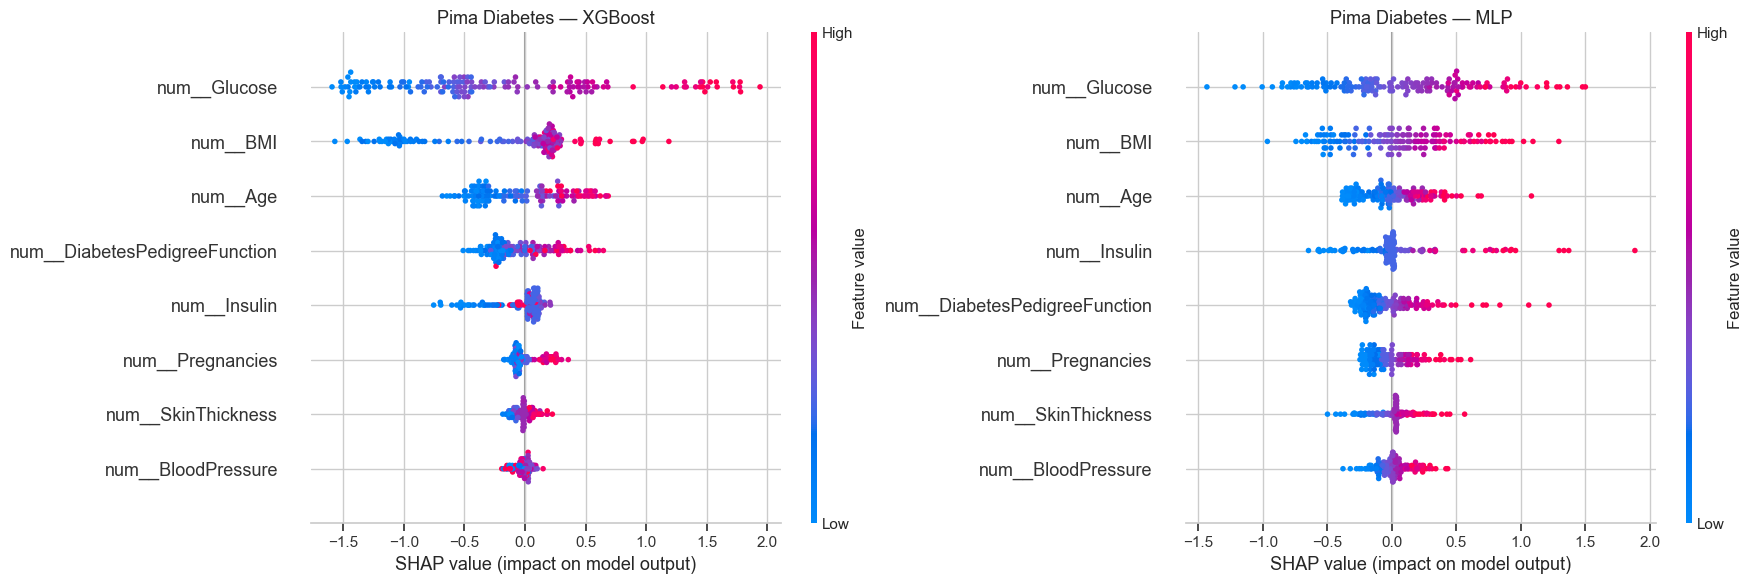

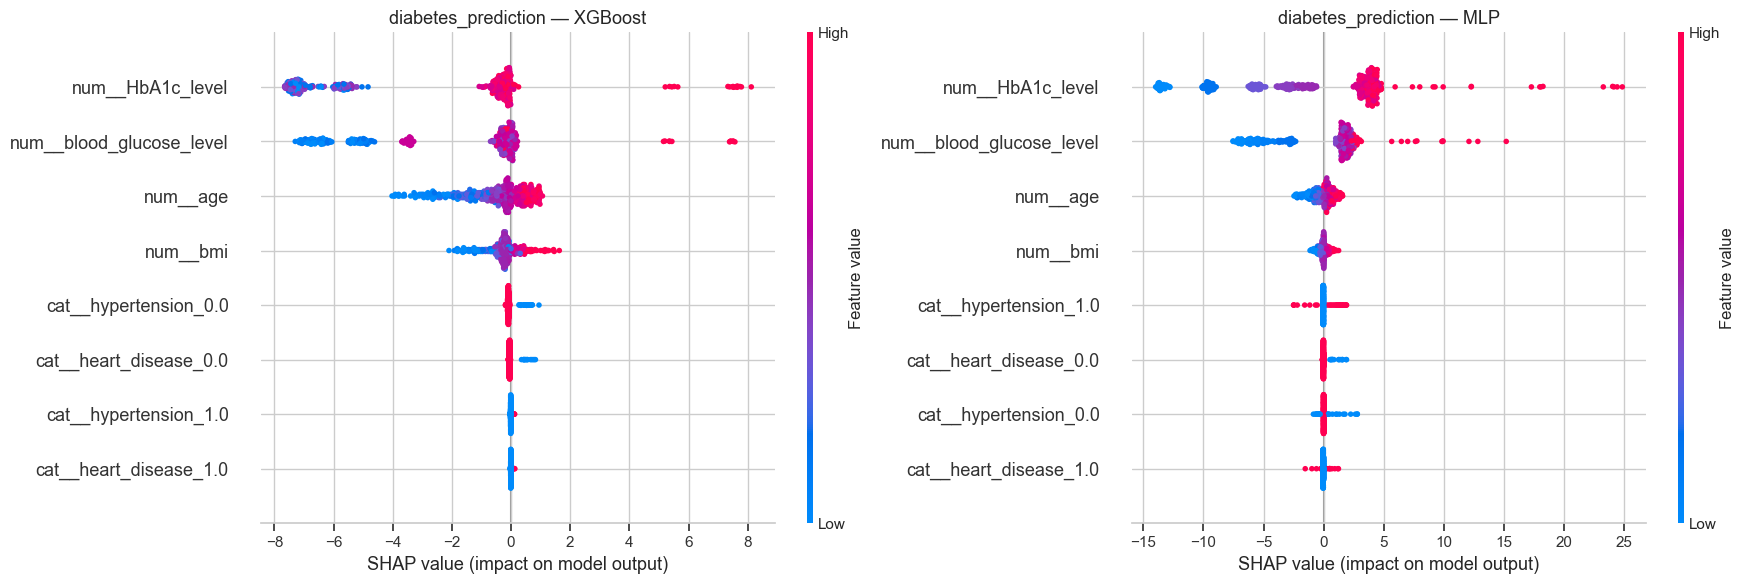

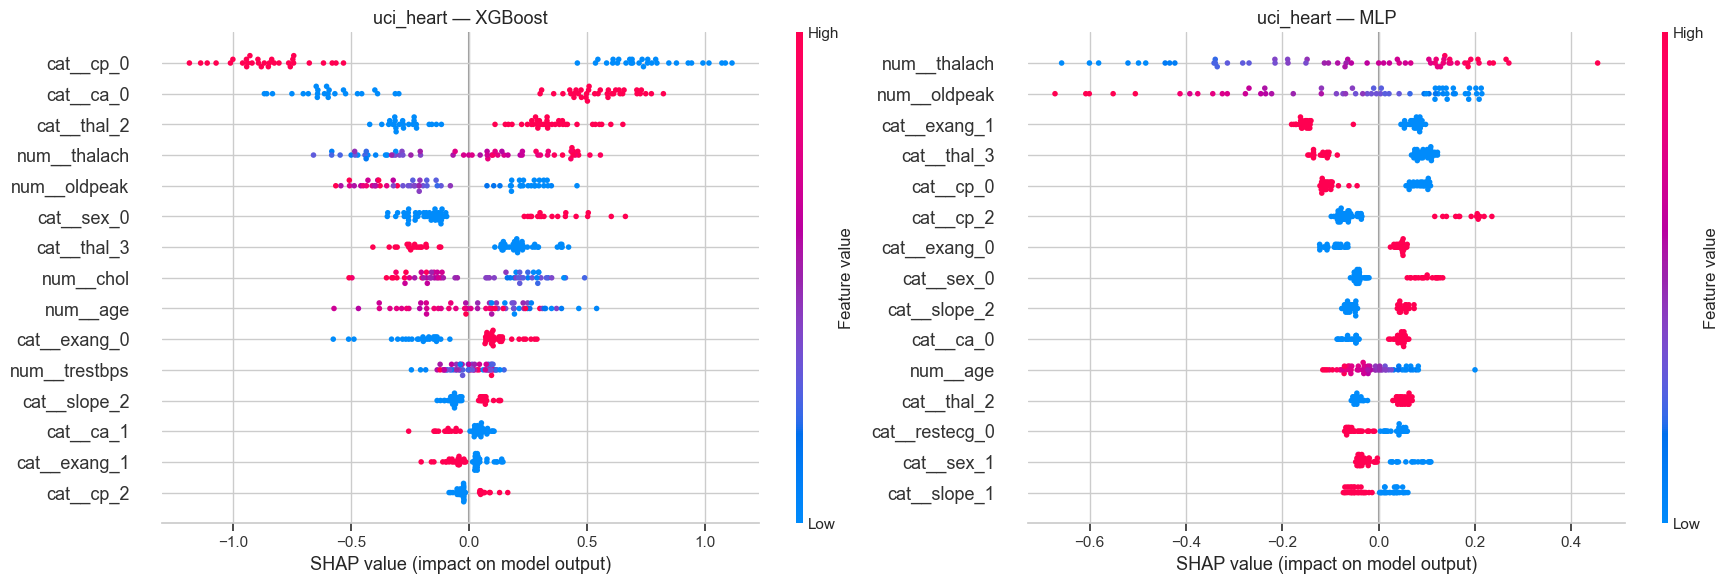

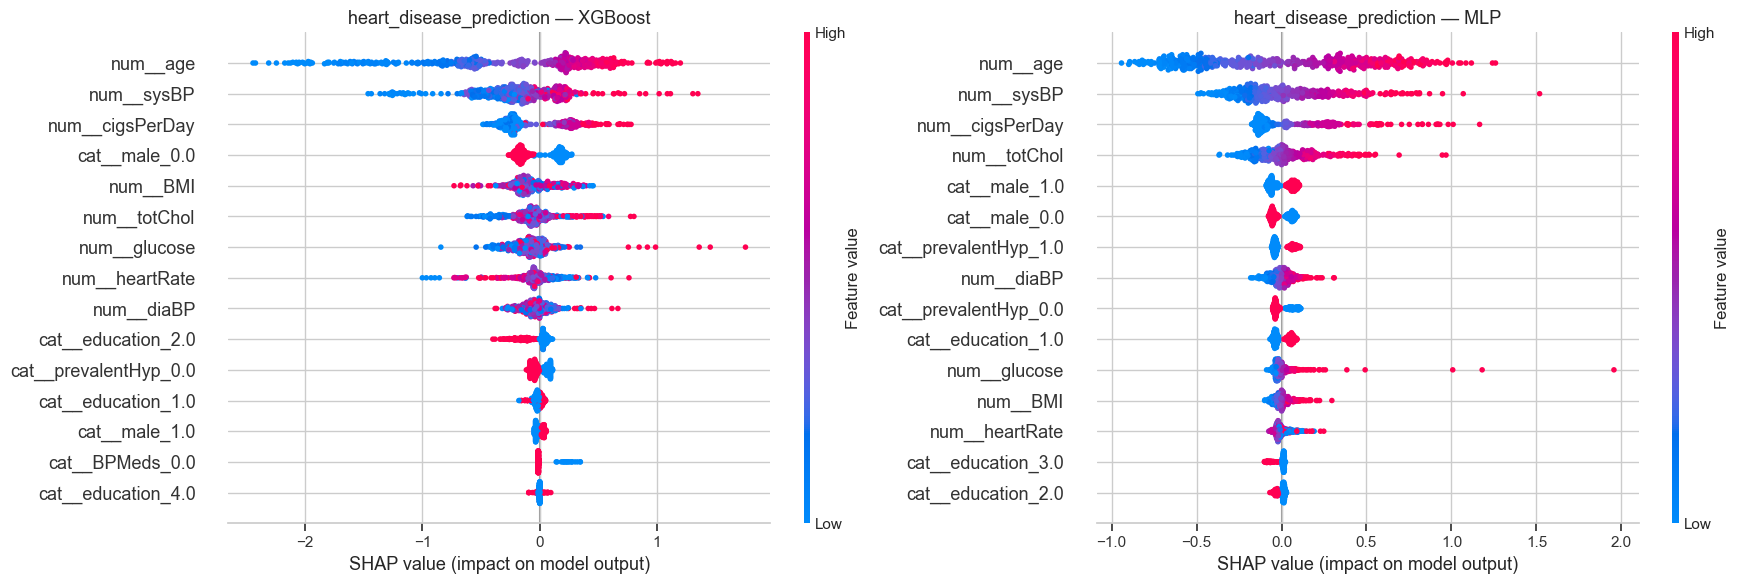

In [22]:
def plot_global_beeswarm(result):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Cap feature display for readability if many features
    max_display = min(15, len(result["feature_names"]))

    plt.sca(axes[0])
    shap.summary_plot(
        result["shap_xgb"],
        features=result["X_xgb_sample"],
        feature_names=result["feature_names"],
        show=False,
        plot_size=None,
        max_display=max_display,
    )
    axes[0].set_title(f"{result['dataset']} — XGBoost", fontsize=13)

    plt.sca(axes[1])
    shap.summary_plot(
        result["shap_mlp"],
        features=result["X_mlp_sample"],
        feature_names=result["feature_names"],
        show=False,
        plot_size=None,
        max_display=max_display,
    )
    axes[1].set_title(f"{result['dataset']} — MLP", fontsize=13)

    plt.tight_layout()
    plt.show()

# Run on all 4 datasets
for name, result in shap_results.items():
    plot_global_beeswarm(result)

### Cell 16: Global SHAP — Feature Ranking Comparison

Computes mean |SHAP| for each feature, ranks them, and  calculates Spearman's rank correlation between models.
- High correlation = models agree on what matters.
- Low correlation = models tell different stories.

In [23]:
def compare_rankings(result):
    feature_names = result["feature_names"]
    shap_xgb = result["shap_xgb"]
    shap_mlp = result["shap_mlp"]

    mean_xgb = np.abs(shap_xgb).mean(axis=0)
    mean_mlp = np.abs(shap_mlp).mean(axis=0)

    rank_xgb = (-mean_xgb).argsort().argsort() + 1
    rank_mlp = (-mean_mlp).argsort().argsort() + 1

    comparison = pd.DataFrame({
        "Feature": feature_names,
        "XGB_mean_SHAP": mean_xgb.round(4),
        "MLP_mean_SHAP": mean_mlp.round(4),
        "XGB_rank": rank_xgb,
        "MLP_rank": rank_mlp,
        "Rank_diff": np.abs(rank_xgb - rank_mlp),
    }).sort_values("XGB_rank")

    rho, p_value = spearmanr(mean_xgb, mean_mlp)

    print(f"\n{'='*60}")
    print(f"  {result['dataset']} — Feature Ranking Comparison")
    print(f"{'='*60}")
    display(comparison)
    print(f"\nSpearman's ρ = {rho:.4f}  (p = {p_value:.4f})")

    if rho > 0.8:
        interp = "→ Strong agreement: models rank features similarly"
    elif rho > 0.5:
        interp = "→ Moderate agreement: some features ranked differently"
    else:
        interp = "→ Weak agreement: models tell different stories"
    print(interp)

    top3_xgb = set(comparison.nsmallest(3, "XGB_rank")["Feature"].tolist())
    top3_mlp = set(comparison.nsmallest(3, "MLP_rank")["Feature"].tolist())
    overlap = top3_xgb & top3_mlp
    print(f"\nTop-3 XGBoost: {top3_xgb}")
    print(f"Top-3 MLP:     {top3_mlp}")
    print(f"Overlap:       {overlap} ({len(overlap)}/3)")

    return rho, len(overlap)

# Store correlations for cross-dataset summary
ranking_results = {}
for name, result in shap_results.items():
    rho, overlap = compare_rankings(result)
    ranking_results[name] = {"rho": rho, "top3_overlap": overlap}


  Pima Diabetes — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
1,num__Glucose,0.8163,0.4833,1,1,0
5,num__BMI,0.4718,0.3568,2,2,0
7,num__Age,0.3218,0.2025,3,3,0
6,num__DiabetesPedigreeFunction,0.2192,0.1902,4,5,1
4,num__Insulin,0.1430,0.1973,5,4,1
0,num__Pregnancies,0.0966,0.1488,6,6,0
3,num__SkinThickness,0.0612,0.1127,7,7,0
2,num__BloodPressure,0.0441,0.1010,8,8,0



Spearman's ρ = 0.9762  (p = 0.0000)
→ Strong agreement: models rank features similarly

Top-3 XGBoost: {'num__BMI', 'num__Glucose', 'num__Age'}
Top-3 MLP:     {'num__BMI', 'num__Glucose', 'num__Age'}
Overlap:       {'num__BMI', 'num__Glucose', 'num__Age'} (3/3)

  diabetes_prediction — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
2,num__HbA1c_level,3.1321,5.3860,1,1,0
3,num__blood_glucose_level,2.2472,3.0128,2,2,0
0,num__age,0.9056,0.6365,3,3,0
1,num__bmi,0.4459,0.2737,4,4,0
4,cat__hypertension_0.0,0.1208,0.0616,5,7,2
6,cat__heart_disease_0.0,0.0715,0.0663,6,6,0
5,cat__hypertension_1.0,0.0129,0.1117,7,5,2
7,cat__heart_disease_1.0,0.0095,0.0530,8,8,0



Spearman's ρ = 0.9048  (p = 0.0020)
→ Strong agreement: models rank features similarly

Top-3 XGBoost: {'num__blood_glucose_level', 'num__age', 'num__HbA1c_level'}
Top-3 MLP:     {'num__blood_glucose_level', 'num__age', 'num__HbA1c_level'}
Overlap:       {'num__blood_glucose_level', 'num__age', 'num__HbA1c_level'} (3/3)

  uci_heart — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
7,cat__cp_0,0.8122,0.0959,1,5,4
21,cat__ca_0,0.5696,0.0523,2,10,8
28,cat__thal_2,0.3176,0.0478,3,12,9
3,num__thalach,0.3092,0.2152,4,1,3
4,num__oldpeak,0.2882,0.1872,5,2,3
5,cat__sex_0,0.2464,0.0584,6,8,2
29,cat__thal_3,0.2302,0.1032,7,4,3
2,num__chol,0.2299,0.0276,8,19,11
0,num__age,0.2053,0.0493,9,11,2
16,cat__exang_0,0.1738,0.0654,10,7,3



Spearman's ρ = 0.7899  (p = 0.0000)
→ Moderate agreement: some features ranked differently

Top-3 XGBoost: {'cat__ca_0', 'cat__cp_0', 'cat__thal_2'}
Top-3 MLP:     {'num__thalach', 'cat__exang_1', 'num__oldpeak'}
Overlap:       set() (0/3)

  heart_disease_prediction — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
0,num__age,0.6643,0.4615,1,1,0
3,num__sysBP,0.3124,0.2216,2,2,0
1,num__cigsPerDay,0.2696,0.1840,3,3,0
8,cat__male_0.0,0.1686,0.0555,4,6,2
5,num__BMI,0.1509,0.0347,5,12,7
2,num__totChol,0.1503,0.1353,6,4,2
7,num__glucose,0.1406,0.0407,7,11,4
6,num__heartRate,0.1247,0.0307,8,13,5
4,num__diaBP,0.0921,0.0472,9,8,1
11,cat__education_2.0,0.0758,0.0168,10,15,5



Spearman's ρ = 0.7558  (p = 0.0000)
→ Moderate agreement: some features ranked differently

Top-3 XGBoost: {'num__age', 'num__cigsPerDay', 'num__sysBP'}
Top-3 MLP:     {'num__age', 'num__cigsPerDay', 'num__sysBP'}
Overlap:       {'num__age', 'num__cigsPerDay', 'num__sysBP'} (3/3)


### Cell 17: Local SHAP — Pick 5 representative patients + bar plots

This code block performs a "micro-level" analysis of the models. Instead of looking at overall feature importance across the whole dataset, it zooms in on individual patients to see exactly how XGBoost and the MLP compare when making a specific clinical prediction.



  LOCAL SHAP: Pima Diabetes
Selected: {'True Positive': 111, 'True Negative': 137, 'Borderline': 55, 'False Positive': 0, 'False Negative': 14}


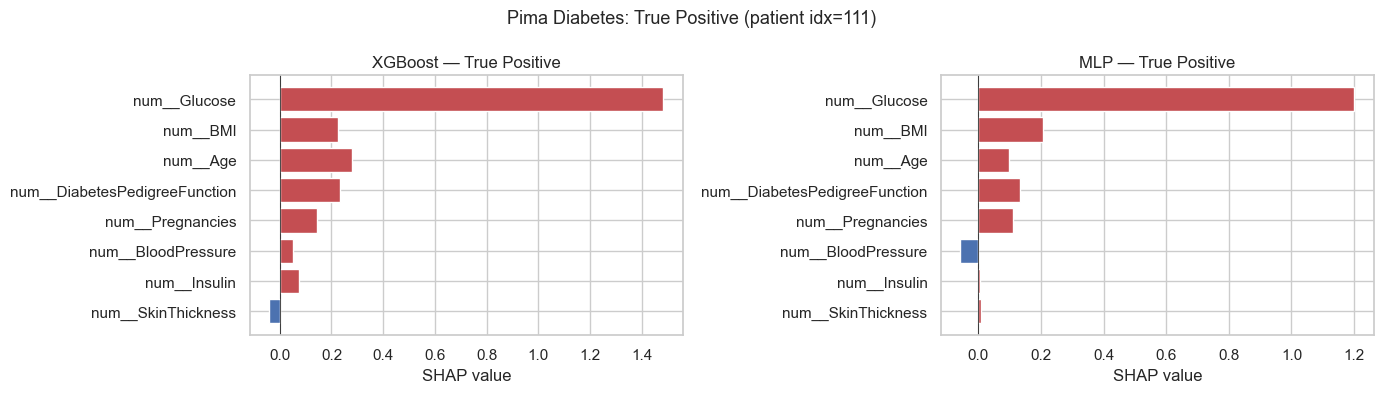

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__DiabetesPedigreeFunction'), np.str_('num__Glucose'), np.str_('num__Age')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__DiabetesPedigreeFunction'), np.str_('num__Glucose')}
  Overlap:   {np.str_('num__DiabetesPedigreeFunction'), np.str_('num__Glucose')} (2/3)



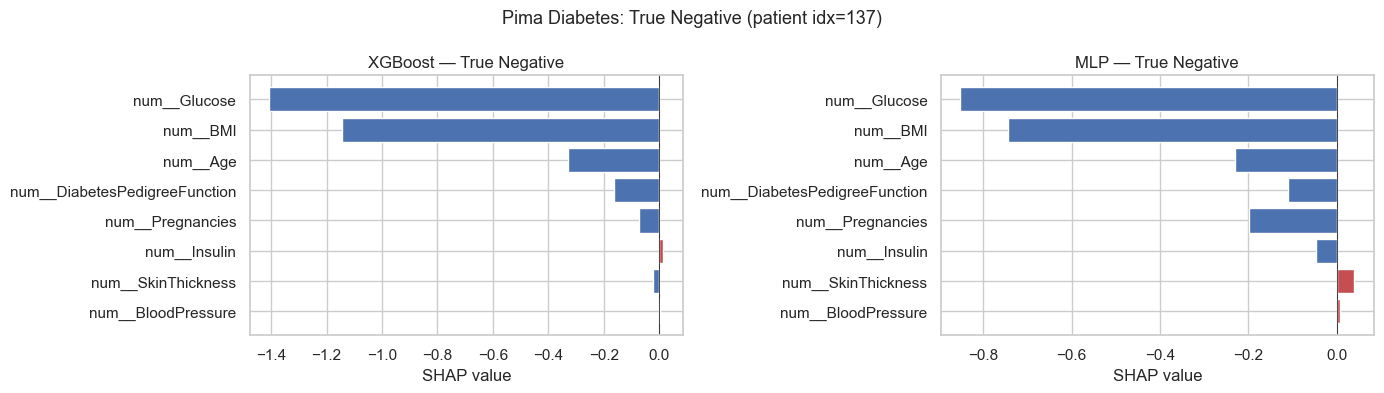

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')}
  Overlap:   {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')} (3/3)



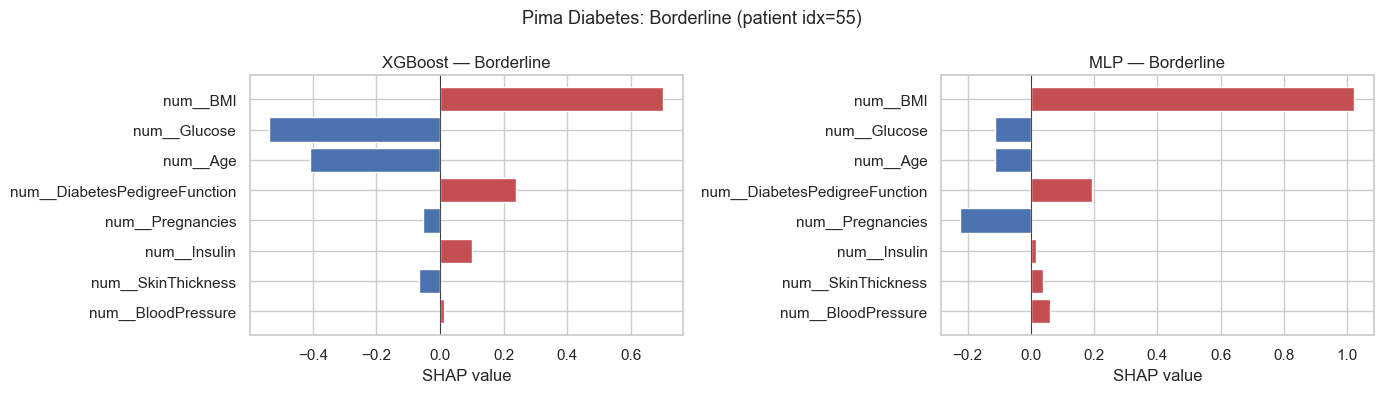

  Sign agreement: 7/8
  Top-3 XGB: {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')}
  Top-3 MLP: {np.str_('num__Pregnancies'), np.str_('num__BMI'), np.str_('num__DiabetesPedigreeFunction')}
  Overlap:   {np.str_('num__BMI')} (1/3)



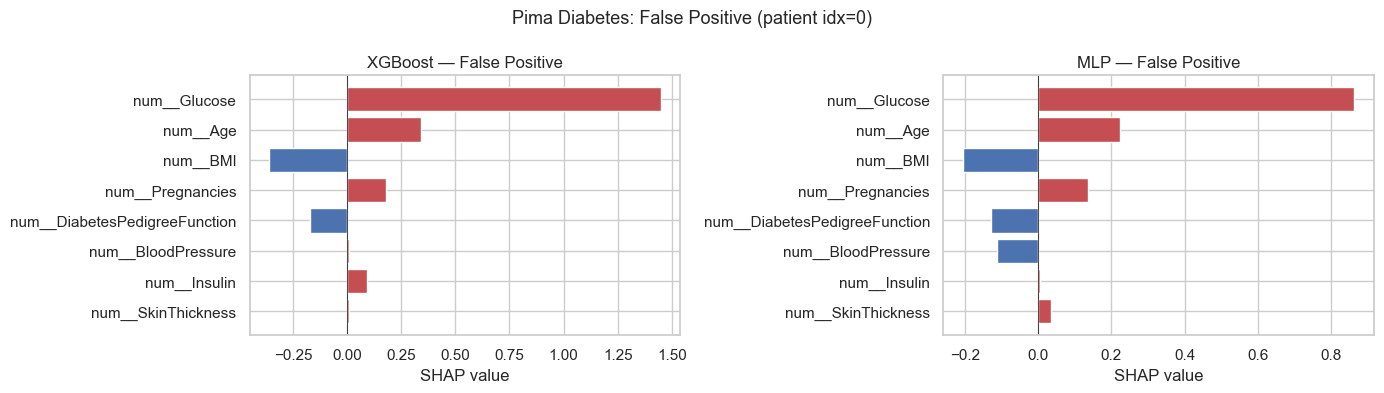

  Sign agreement: 7/8
  Top-3 XGB: {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')}
  Overlap:   {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__Age')} (3/3)



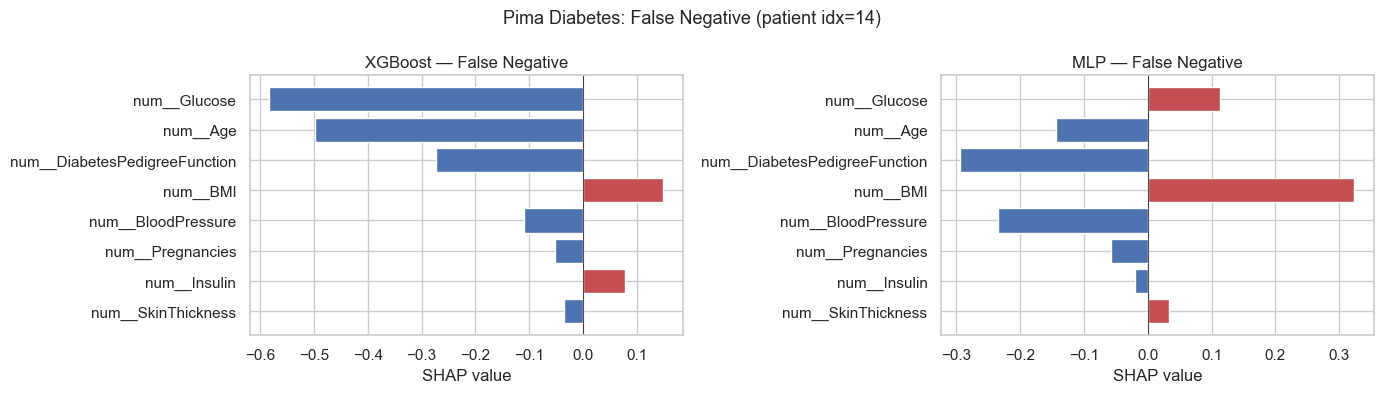

  Sign agreement: 5/8
  Top-3 XGB: {np.str_('num__DiabetesPedigreeFunction'), np.str_('num__Glucose'), np.str_('num__Age')}
  Top-3 MLP: {np.str_('num__BloodPressure'), np.str_('num__BMI'), np.str_('num__DiabetesPedigreeFunction')}
  Overlap:   {np.str_('num__DiabetesPedigreeFunction')} (1/3)


  LOCAL SHAP: diabetes_prediction
Selected: {'True Positive': 331, 'True Negative': 52, 'Borderline': 281, 'False Positive': 14, 'False Negative': 21}


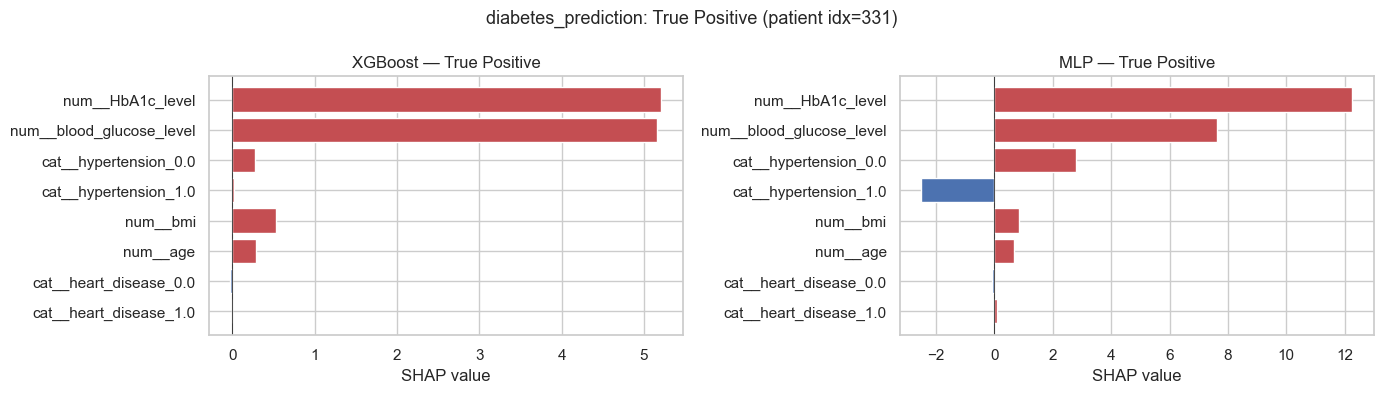

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__blood_glucose_level'), np.str_('num__HbA1c_level'), np.str_('num__bmi')}
  Top-3 MLP: {np.str_('num__blood_glucose_level'), np.str_('cat__hypertension_0.0'), np.str_('num__HbA1c_level')}
  Overlap:   {np.str_('num__blood_glucose_level'), np.str_('num__HbA1c_level')} (2/3)



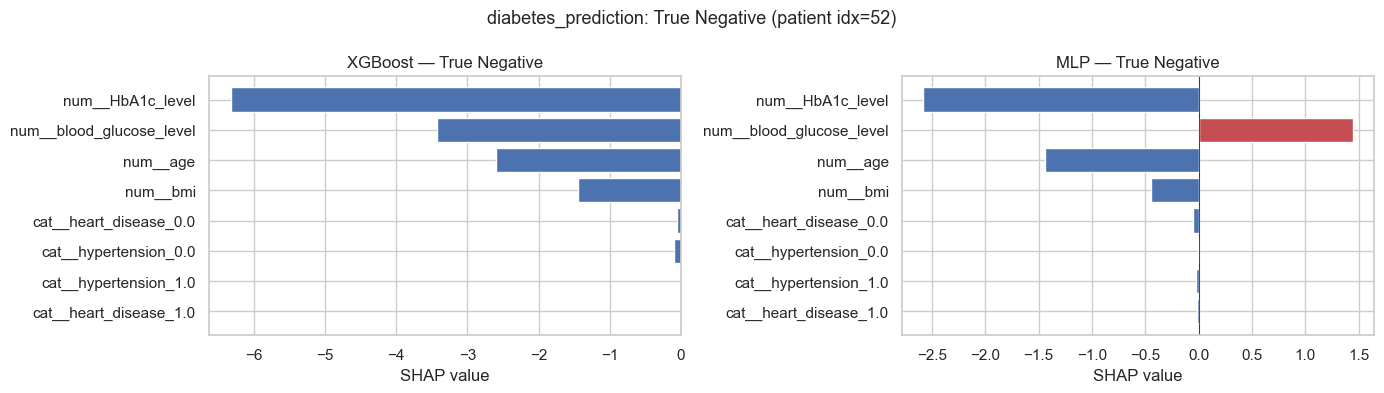

  Sign agreement: 7/8
  Top-3 XGB: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__HbA1c_level')}
  Top-3 MLP: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__HbA1c_level')}
  Overlap:   {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__HbA1c_level')} (3/3)



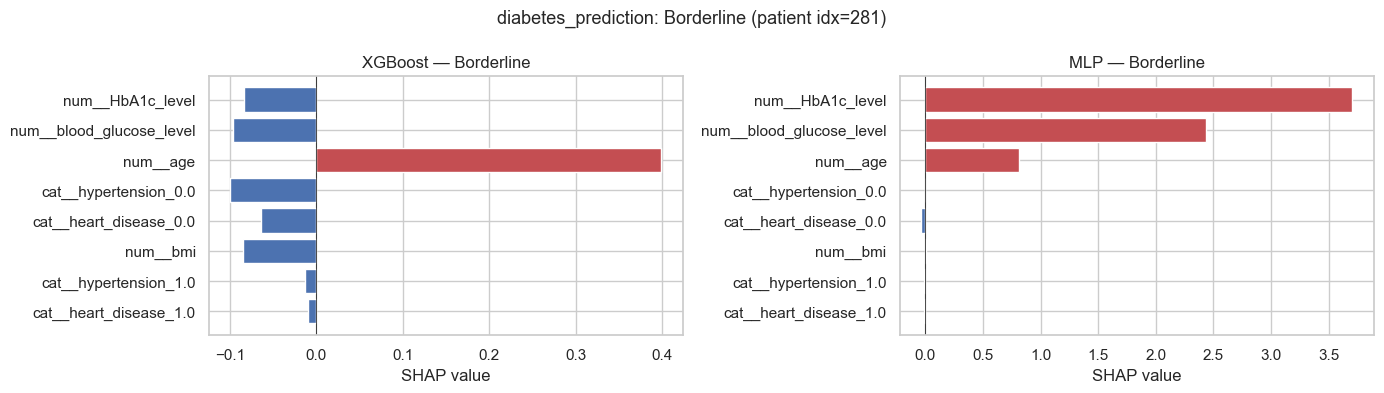

  Sign agreement: 5/8
  Top-3 XGB: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('cat__hypertension_0.0')}
  Top-3 MLP: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__HbA1c_level')}
  Overlap:   {np.str_('num__blood_glucose_level'), np.str_('num__age')} (2/3)



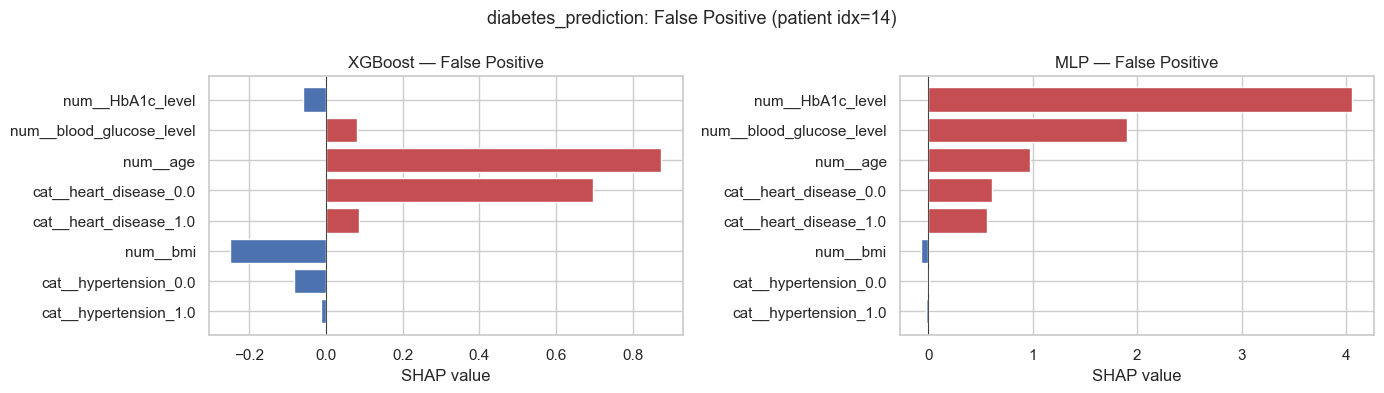

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__age'), np.str_('cat__heart_disease_0.0'), np.str_('num__bmi')}
  Top-3 MLP: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__HbA1c_level')}
  Overlap:   {np.str_('num__age')} (1/3)



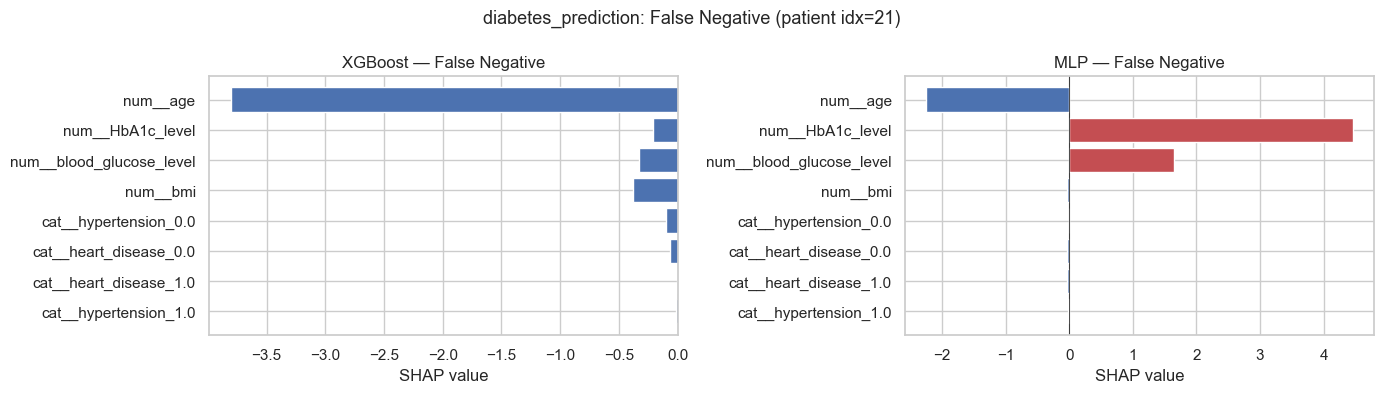

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__bmi')}
  Top-3 MLP: {np.str_('num__blood_glucose_level'), np.str_('num__age'), np.str_('num__HbA1c_level')}
  Overlap:   {np.str_('num__blood_glucose_level'), np.str_('num__age')} (2/3)


  LOCAL SHAP: uci_heart
Selected: {'True Positive': 18, 'True Negative': 21, 'Borderline': 28, 'False Positive': 1, 'False Negative': 11}


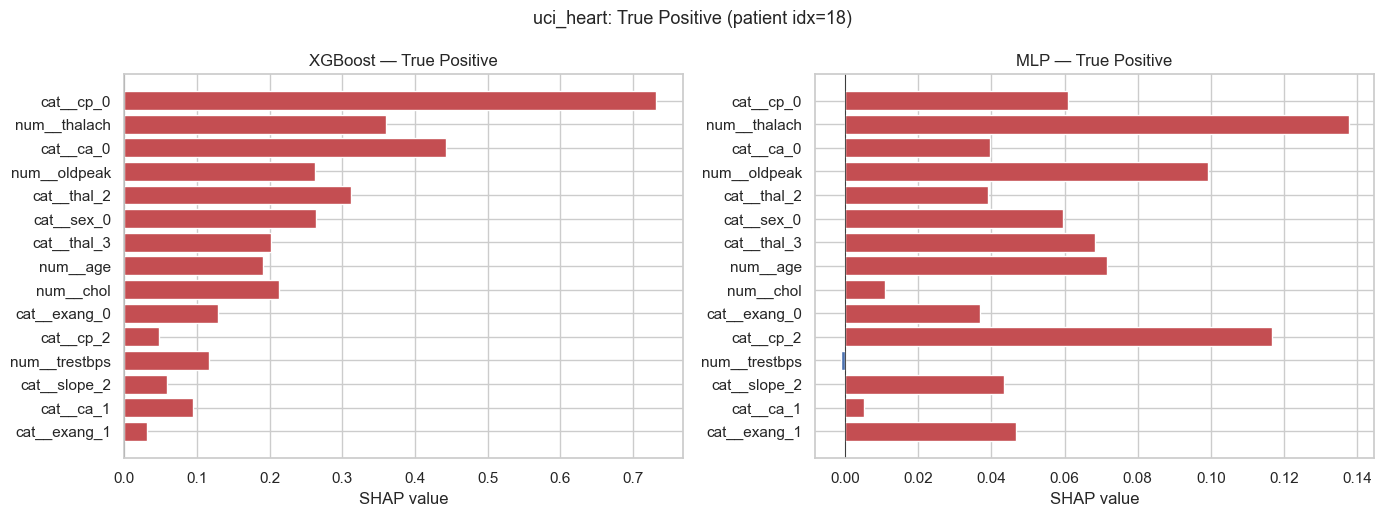

  Sign agreement: 22/30
  Top-3 XGB: {np.str_('cat__ca_0'), np.str_('cat__cp_0'), np.str_('num__thalach')}
  Top-3 MLP: {np.str_('num__thalach'), np.str_('cat__cp_2'), np.str_('num__oldpeak')}
  Overlap:   {np.str_('num__thalach')} (1/3)



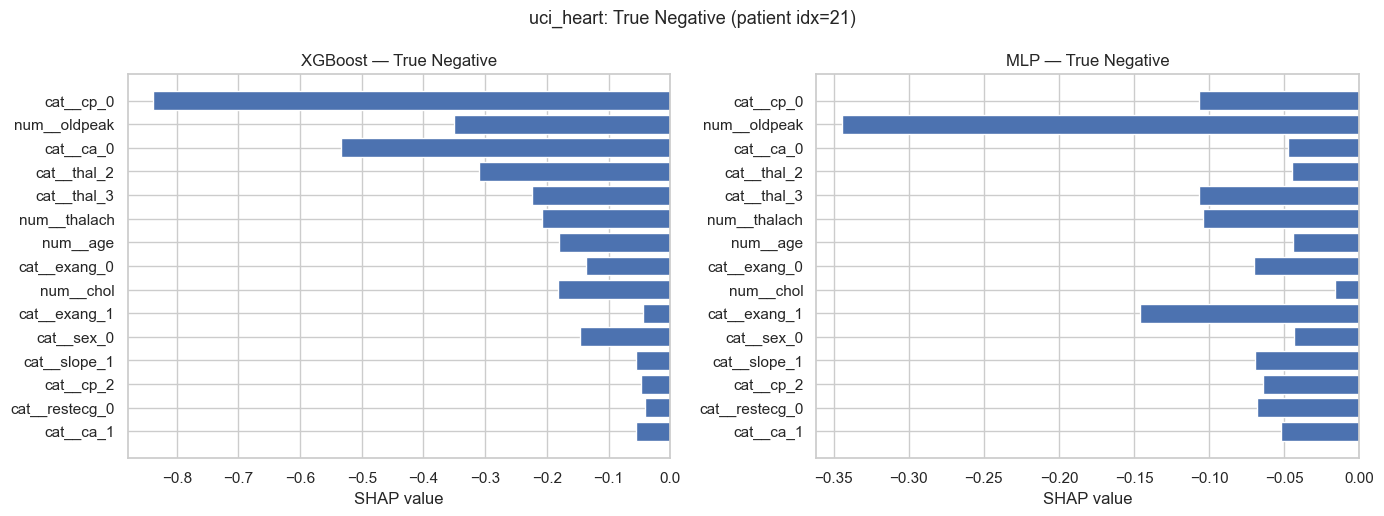

  Sign agreement: 22/30
  Top-3 XGB: {np.str_('cat__ca_0'), np.str_('cat__cp_0'), np.str_('num__oldpeak')}
  Top-3 MLP: {np.str_('cat__cp_0'), np.str_('cat__exang_1'), np.str_('num__oldpeak')}
  Overlap:   {np.str_('cat__cp_0'), np.str_('num__oldpeak')} (2/3)



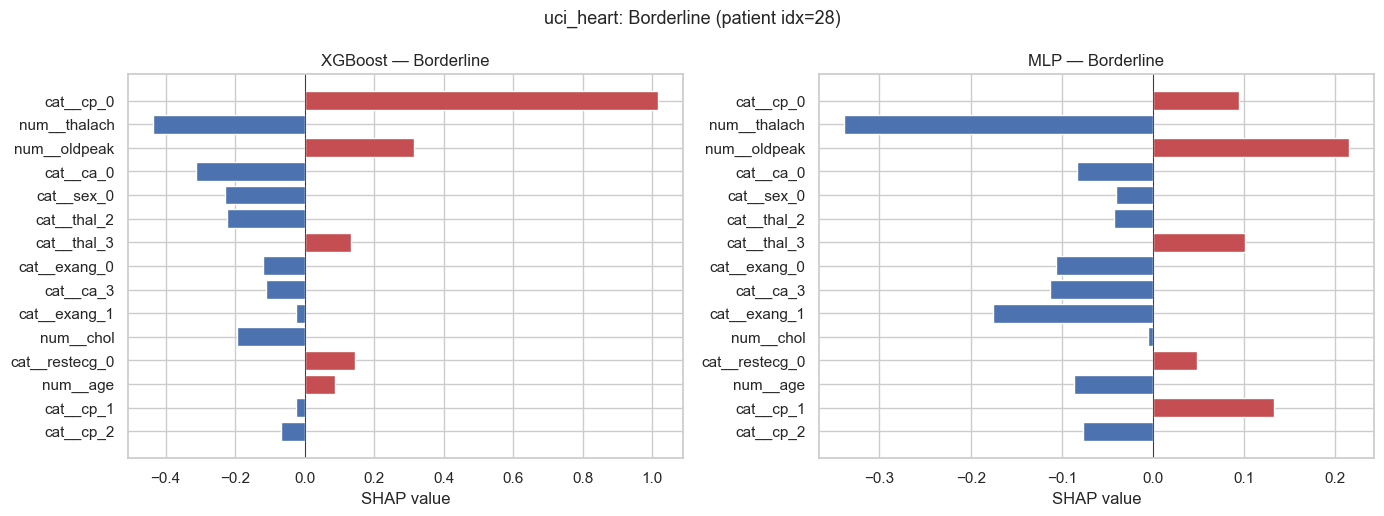

  Sign agreement: 22/30
  Top-3 XGB: {np.str_('num__thalach'), np.str_('cat__cp_0'), np.str_('num__oldpeak')}
  Top-3 MLP: {np.str_('num__thalach'), np.str_('cat__exang_1'), np.str_('num__oldpeak')}
  Overlap:   {np.str_('num__thalach'), np.str_('num__oldpeak')} (2/3)



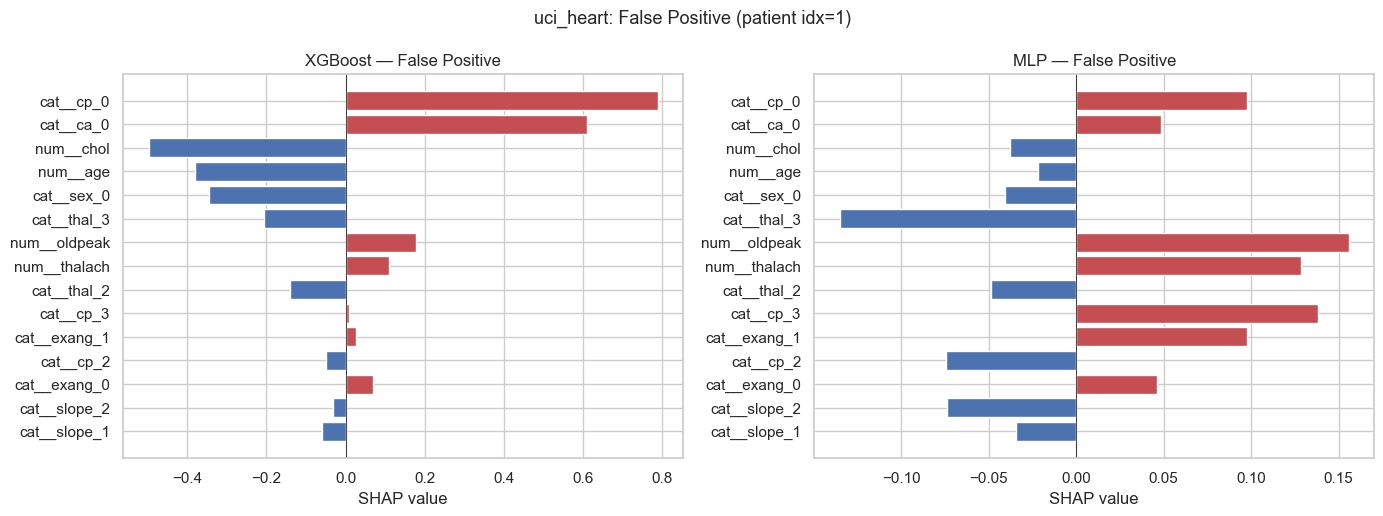

  Sign agreement: 24/30
  Top-3 XGB: {np.str_('cat__ca_0'), np.str_('cat__cp_0'), np.str_('num__chol')}
  Top-3 MLP: {np.str_('cat__thal_3'), np.str_('num__oldpeak'), np.str_('cat__cp_3')}
  Overlap:   set() (0/3)



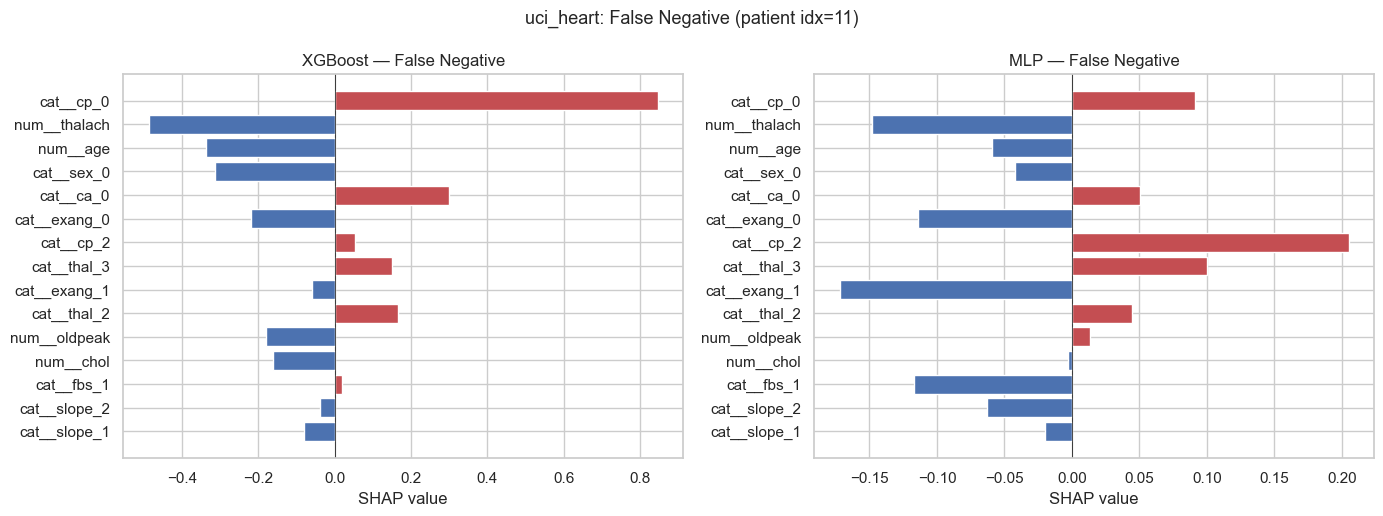

  Sign agreement: 23/30
  Top-3 XGB: {np.str_('num__thalach'), np.str_('cat__cp_0'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__thalach'), np.str_('cat__exang_1'), np.str_('cat__cp_2')}
  Overlap:   {np.str_('num__thalach')} (1/3)


  LOCAL SHAP: heart_disease_prediction
Selected: {'True Positive': 342, 'True Negative': 272, 'Borderline': 476, 'False Positive': 4, 'False Negative': 9}


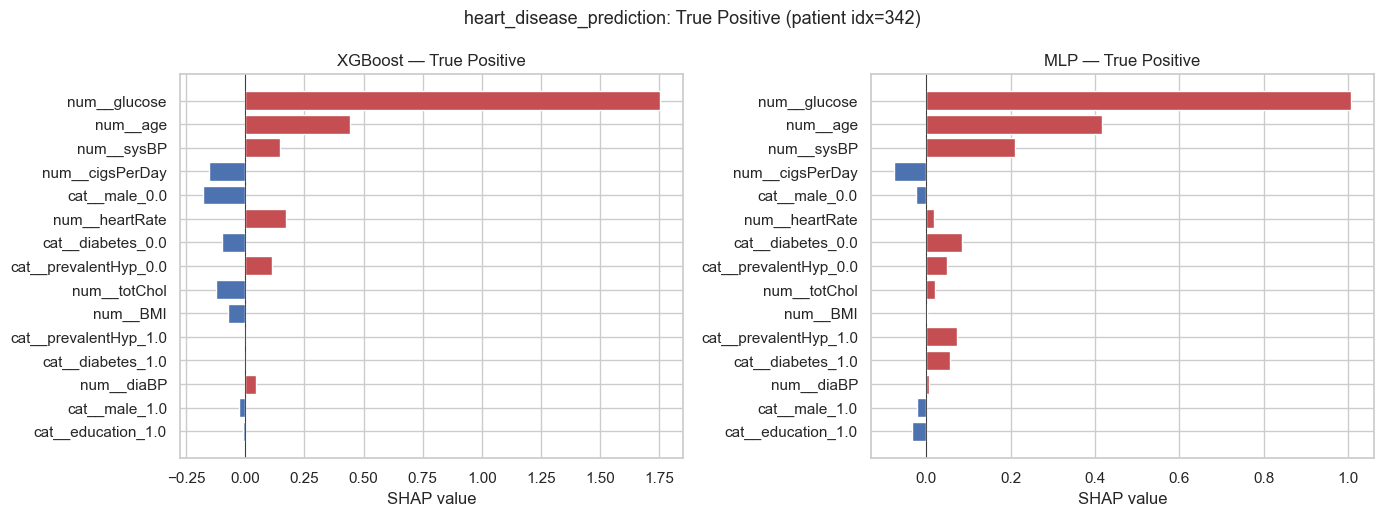

  Sign agreement: 11/22
  Top-3 XGB: {np.str_('num__age'), np.str_('num__glucose'), np.str_('cat__male_0.0')}
  Top-3 MLP: {np.str_('num__age'), np.str_('num__glucose'), np.str_('num__sysBP')}
  Overlap:   {np.str_('num__age'), np.str_('num__glucose')} (2/3)



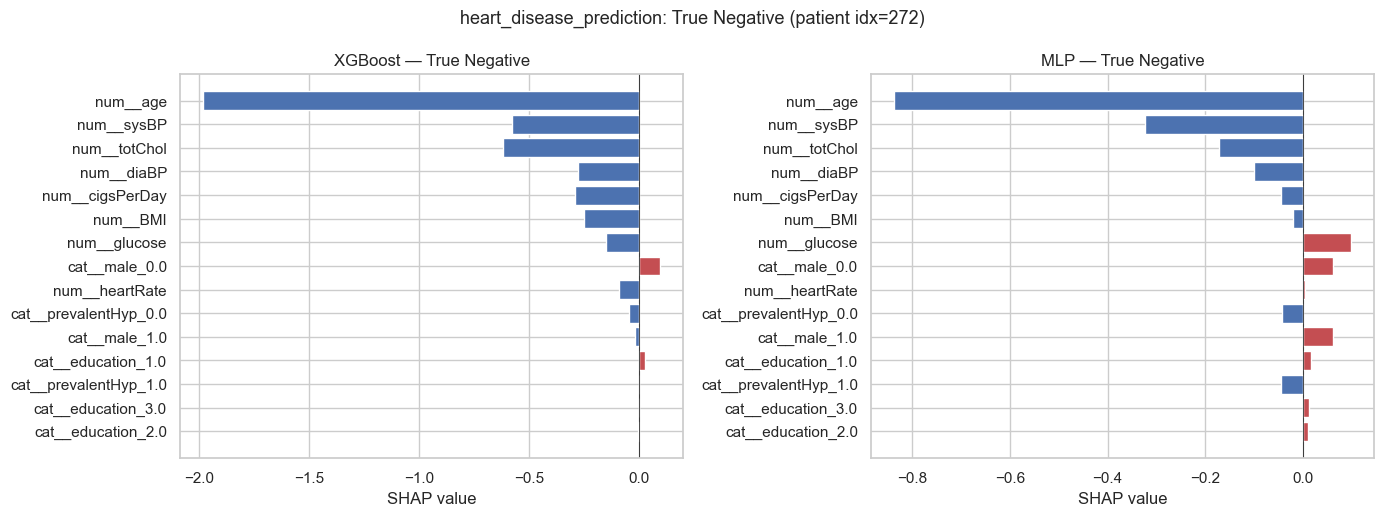

  Sign agreement: 11/22
  Top-3 XGB: {np.str_('num__totChol'), np.str_('num__age'), np.str_('num__sysBP')}
  Top-3 MLP: {np.str_('num__totChol'), np.str_('num__age'), np.str_('num__sysBP')}
  Overlap:   {np.str_('num__totChol'), np.str_('num__age'), np.str_('num__sysBP')} (3/3)



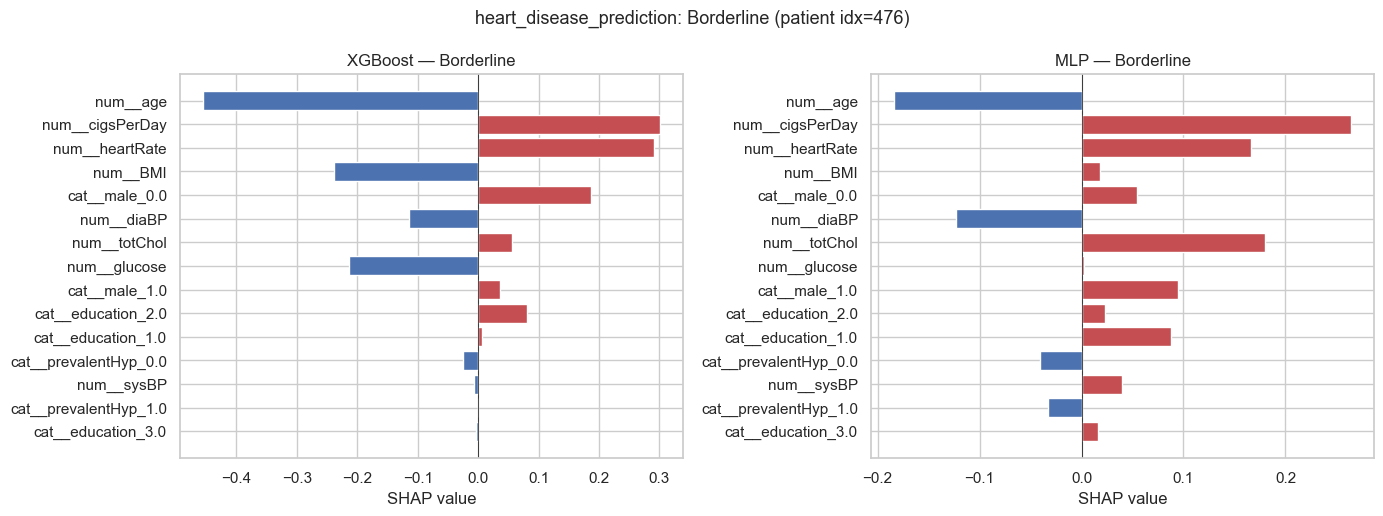

  Sign agreement: 10/22
  Top-3 XGB: {np.str_('num__age'), np.str_('num__heartRate'), np.str_('num__cigsPerDay')}
  Top-3 MLP: {np.str_('num__totChol'), np.str_('num__age'), np.str_('num__cigsPerDay')}
  Overlap:   {np.str_('num__age'), np.str_('num__cigsPerDay')} (2/3)



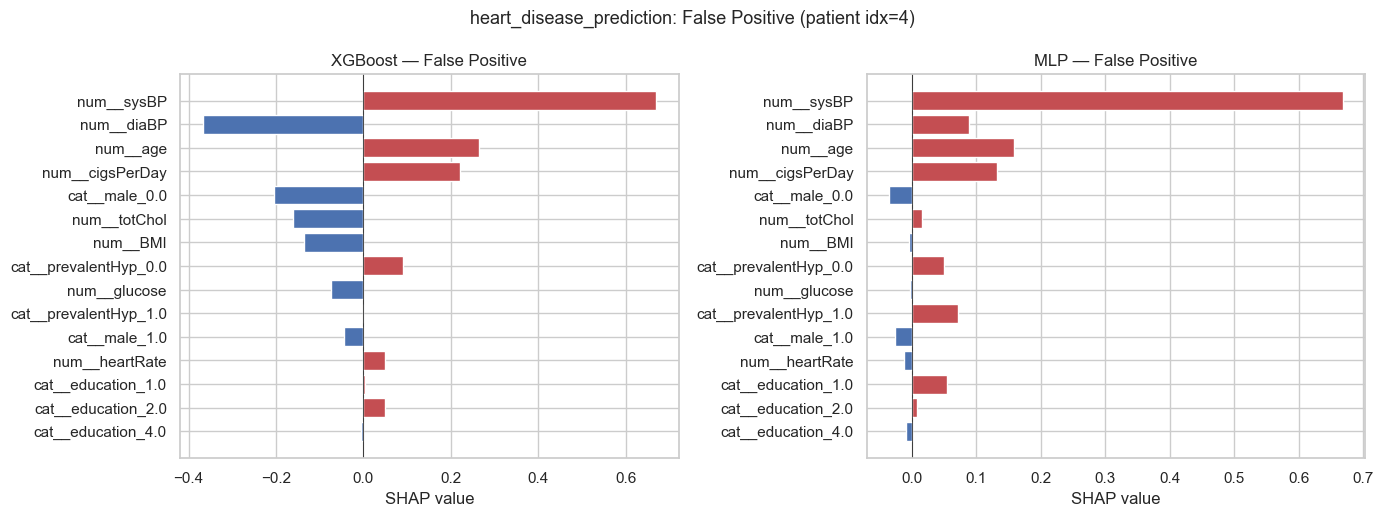

  Sign agreement: 11/22
  Top-3 XGB: {np.str_('num__sysBP'), np.str_('num__age'), np.str_('num__diaBP')}
  Top-3 MLP: {np.str_('num__sysBP'), np.str_('num__age'), np.str_('num__cigsPerDay')}
  Overlap:   {np.str_('num__sysBP'), np.str_('num__age')} (2/3)



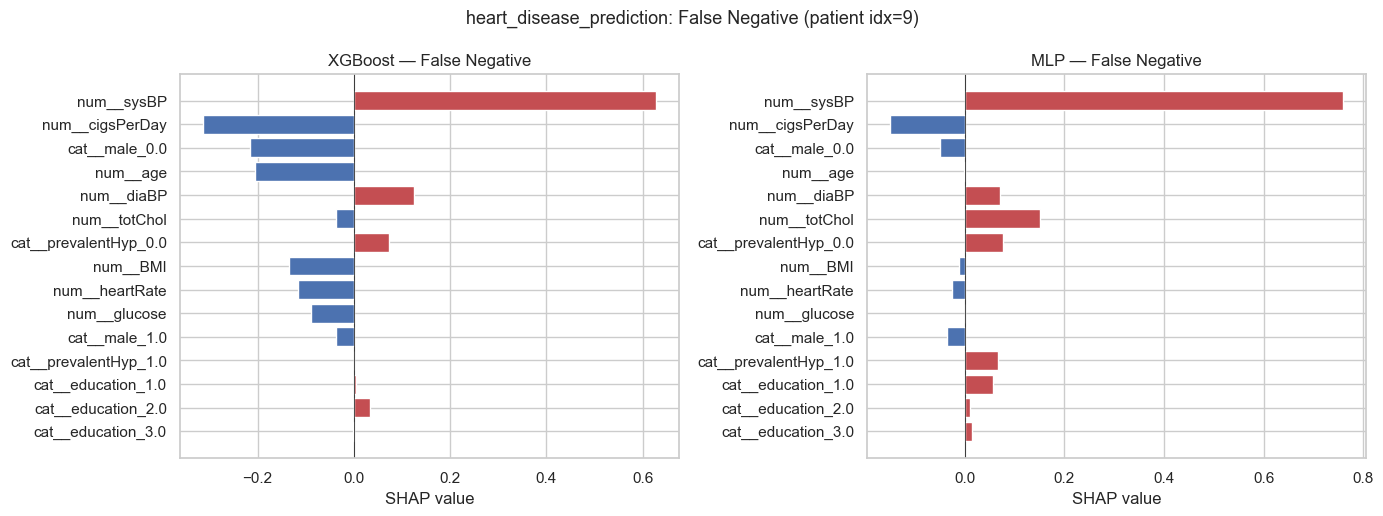

  Sign agreement: 12/22
  Top-3 XGB: {np.str_('num__sysBP'), np.str_('cat__male_0.0'), np.str_('num__cigsPerDay')}
  Top-3 MLP: {np.str_('num__totChol'), np.str_('num__sysBP'), np.str_('num__cigsPerDay')}
  Overlap:   {np.str_('num__sysBP'), np.str_('num__cigsPerDay')} (2/3)



In [24]:
""""Rather than plotting random patients,
this function strategically selects up to 5 specific patient "archetypes" to evaluate how the models behave under different conditions.
It uses the XGBoost predictions to find"""

def select_patients(result):
    """Select 5 representative patients from the SHAP sample."""
    y = result["y_sample"]
    xgb_prob = result["xgb_proba"]
    mlp_prob = result["mlp_proba"]
    xgb_pred = (xgb_prob >= 0.5).astype(int)

    df = pd.DataFrame({
        "y_true": y,
        "xgb_pred": xgb_pred,
        "xgb_prob": xgb_prob,
        "mlp_prob": mlp_prob,
    }).reset_index(drop=True)

    patients = {}

    tp = df[(df["y_true"] == 1) & (df["xgb_pred"] == 1)]
    if len(tp) > 0:
        patients["True Positive"] = int(tp["xgb_prob"].idxmax())

    tn = df[(df["y_true"] == 0) & (df["xgb_pred"] == 0)]
    if len(tn) > 0:
        patients["True Negative"] = int(tn["xgb_prob"].idxmin())

    patients["Borderline"] = int((df["xgb_prob"] - 0.5).abs().idxmin())

    fp = df[(df["y_true"] == 0) & (df["xgb_pred"] == 1)]
    if len(fp) > 0:
        patients["False Positive"] = int(fp.index[0])

    fn = df[(df["y_true"] == 1) & (df["xgb_pred"] == 0)]
    if len(fn) > 0:
        patients["False Negative"] = int(fn.index[0])

    return patients


def plot_patient_local_shap(result, patients):
    """For each archetype, side-by-side bar charts of SHAP values."""
    feature_names = result["feature_names"]
    n_features = len(feature_names)
    # Cap displayed features
    show_n = min(15, n_features)

    for ptype, idx in patients.items():
        xgb_vals = result["shap_xgb"][idx]
        mlp_vals = result["shap_mlp"][idx]

        # Pick top features by combined importance for cleaner plot
        combined_importance = np.abs(xgb_vals) + np.abs(mlp_vals)
        top_idx = np.argsort(-combined_importance)[:show_n]
        feat_subset = [feature_names[i] for i in top_idx]
        xgb_subset = xgb_vals[top_idx]
        mlp_subset = mlp_vals[top_idx]

        fig, axes = plt.subplots(1, 2, figsize=(14, max(4, show_n * 0.35)))
        y_pos = np.arange(show_n)

        axes[0].barh(y_pos, xgb_subset,
                     color=["#C44E52" if v > 0 else "#4C72B0" for v in xgb_subset])
        axes[0].set_yticks(y_pos)
        axes[0].set_yticklabels(feat_subset)
        axes[0].invert_yaxis()
        axes[0].set_title(f"XGBoost — {ptype}")
        axes[0].set_xlabel("SHAP value")
        axes[0].axvline(0, color="black", linewidth=0.5)

        axes[1].barh(y_pos, mlp_subset,
                     color=["#C44E52" if v > 0 else "#4C72B0" for v in mlp_subset])
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(feat_subset)
        axes[1].invert_yaxis()
        axes[1].set_title(f"MLP — {ptype}")
        axes[1].set_xlabel("SHAP value")
        axes[1].axvline(0, color="black", linewidth=0.5)

        plt.suptitle(f"{result['dataset']}: {ptype} (patient idx={idx})", fontsize=13)
        plt.tight_layout()
        plt.show()

        # Quick metrics
        sign_agree = np.sum(np.sign(xgb_vals) == np.sign(mlp_vals))
        top3_xgb = set(np.array(feature_names)[np.argsort(-np.abs(xgb_vals))[:3]])
        top3_mlp = set(np.array(feature_names)[np.argsort(-np.abs(mlp_vals))[:3]])
        overlap = top3_xgb & top3_mlp
        print(f"  Sign agreement: {sign_agree}/{n_features}")
        print(f"  Top-3 XGB: {top3_xgb}")
        print(f"  Top-3 MLP: {top3_mlp}")
        print(f"  Overlap:   {overlap} ({len(overlap)}/3)\n")

# Run for each dataset
for name, result in shap_results.items():
    print(f"\n{'='*60}\n  LOCAL SHAP: {name}\n{'='*60}")
    patients = select_patients(result)
    print(f"Selected: {patients}")
    plot_patient_local_shap(result, patients)

### Cell 17b · Sign Agreement Summary (across 5 archetypes)

For each (dataset, archetype) pair: count features where sign(SHAP_xgb) == sign(SHAP_mlp), express as % of total features.


In [25]:
sign_agreement_records = []
for name, result in shap_results.items():
    patients     = select_patients(result)
    feature_names = result["feature_names"]
    n_features   = len(feature_names)
    for ptype, idx in patients.items():
        xgb_vals = result["shap_xgb"][idx]
        mlp_vals = result["shap_mlp"][idx]
        sign_agree = int(np.sum(np.sign(xgb_vals) == np.sign(mlp_vals)))
        pct = 100.0 * sign_agree / n_features
        sign_agreement_records.append({
            "Dataset":            name,
            "Archetype":          ptype,
            "Patient_Idx":        idx,
            "Sign_Agree":         sign_agree,
            "N_Features":         n_features,
            "Pct_Sign_Agreement": round(pct, 2),
        })

sign_df = pd.DataFrame(sign_agreement_records)
print("=== Per-archetype Sign Agreement ===")
display(sign_df)

range_summary = (
    sign_df.groupby("Dataset")["Pct_Sign_Agreement"]
           .agg(min_pct="min", max_pct="max", mean_pct="mean")
           .round(1)
           .reindex(["Pima Diabetes", "diabetes_prediction",
                     "uci_heart", "heart_disease_prediction"])
)
print("\n=== Range across 5 archetypes — USE THESE FOR SLIDE 13 ===")
display(range_summary)

overall_mean = sign_df["Pct_Sign_Agreement"].mean()
print(f"\nOverall mean sign agreement across all (dataset, archetype) pairs: {overall_mean:.1f}%")

=== Per-archetype Sign Agreement ===


,Dataset,Archetype,Patient_Idx,Sign_Agree,N_Features,Pct_Sign_Agreement
0,Pima Diabetes,True Positive,111,6,8,75.00
1,Pima Diabetes,True Negative,137,6,8,75.00
2,Pima Diabetes,Borderline,55,7,8,87.50
3,Pima Diabetes,False Positive,0,7,8,87.50
4,Pima Diabetes,False Negative,14,5,8,62.50
5,diabetes_prediction,True Positive,331,6,8,75.00
6,diabetes_prediction,True Negative,52,7,8,87.50
7,diabetes_prediction,Borderline,281,5,8,62.50
8,diabetes_prediction,False Positive,14,6,8,75.00
9,diabetes_prediction,False Negative,21,6,8,75.00



=== Range across 5 archetypes — USE THESE FOR SLIDE 13 ===


,min_pct,max_pct,mean_pct
Dataset,,,
Pima Diabetes,62.5,87.5,77.5
diabetes_prediction,62.5,87.5,75.0
uci_heart,73.3,80.0,75.3
heart_disease_prediction,45.4,54.6,50.0



Overall mean sign agreement across all (dataset, archetype) pairs: 69.5%


### Cell 18: Cross-Dataset

This code block directly addresses the third major hypothesis of our study (Cross-Disease Consistency). It aggregates the SHAP consistency metrics calculated earlier and tests whether the models diverge in the same way for heart disease as they do for diabetes.

In [26]:
# Explicit mapping eliminates the case-sensitivity bug.

DISEASE_MAP = {
    "Pima Diabetes":            "Diabetes",
    "diabetes_prediction":      "Diabetes",
    "uci_heart":                "Heart",
    "heart_disease_prediction": "Heart",
}

summary = pd.DataFrame([
    {
        "Dataset":      name,
        "Spearman_rho": round(r["rho"], 4),
        "Top3_overlap": f"{r['top3_overlap']}/3",
        "Disease":      DISEASE_MAP[name],
    }
    for name, r in ranking_results.items()
])
print("=== CROSS-DATASET SHAP CONSISTENCY ===\n")
display(summary)

diab_avg  = summary.loc[summary["Disease"] == "Diabetes", "Spearman_rho"].mean()
heart_avg = summary.loc[summary["Disease"] == "Heart",    "Spearman_rho"].mean()
gap = abs(diab_avg - heart_avg)

print(f"\nDiabetes average ρ: {diab_avg:.4f}")
print(f"Heart average ρ:    {heart_avg:.4f}")
print(f"Divergence gap:     {gap:.4f}")

if gap < 0.1:
    print("\n→ Cross-disease consistency is similar.")
    print("  Divergence is NOT disease-specific; it appears to be driven by")
    print("  model architecture and/or the choice of explainer (see Cell 22).")
else:
    print(f"\n→ Consistency differs between diseases (gap = {gap:.4f}).")
    print("  Divergence patterns may be DISEASE-SPECIFIC.")

=== CROSS-DATASET SHAP CONSISTENCY ===



,Dataset,Spearman_rho,Top3_overlap,Disease
0,Pima Diabetes,0.9762,3/3,Diabetes
1,diabetes_prediction,0.9048,3/3,Diabetes
2,uci_heart,0.7899,0/3,Heart
3,heart_disease_prediction,0.7558,3/3,Heart



Diabetes average ρ: 0.9405
Heart average ρ:    0.7729
Divergence gap:     0.1676

→ Consistency differs between diseases (gap = 0.1676).
  Divergence patterns may be DISEASE-SPECIFIC.


### Cell 19: Categorical vs. Continuous Disagreement Analysis

Because XGBoost and MLP base values and SHAP scales often differ, comparing raw absolute SHAP differences can be statistically invalid. Instead, this implementation converts SHAP values to local feature importance ranks for each patient, calculates the rank difference, and tests whether cat__ features experience higher rank volatility than num__ features.


 Step 5: Feature Type Divergence for Pima Diabetes
--- Step 5: Categorical vs. Continuous Divergence Analysis ---
Mean Rank Difference (Categorical): nan positions
Mean Rank Difference (Continuous):  1.54 positions
Mann-Whitney U Statistic: nan, p-value: nan

Conclusion: FAIL TO REJECT null hypothesis.
No significant evidence that divergence is tied to feature type.


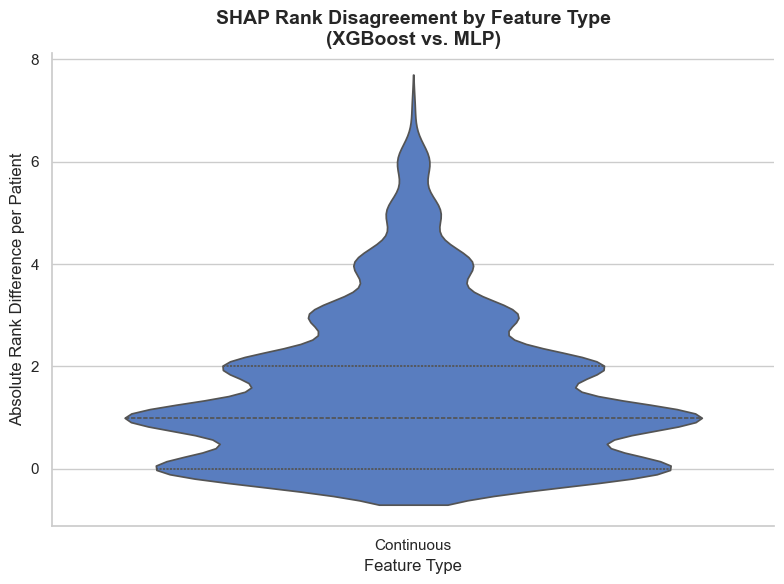


 Step 5: Feature Type Divergence for diabetes_prediction
--- Step 5: Categorical vs. Continuous Divergence Analysis ---
Mean Rank Difference (Categorical): 1.96 positions
Mean Rank Difference (Continuous):  1.50 positions
Mann-Whitney U Statistic: 2468351.5, p-value: 8.0675e-40

Conclusion: REJECT null hypothesis.
There is a statistically significant difference in how models rank categorical vs. continuous features.


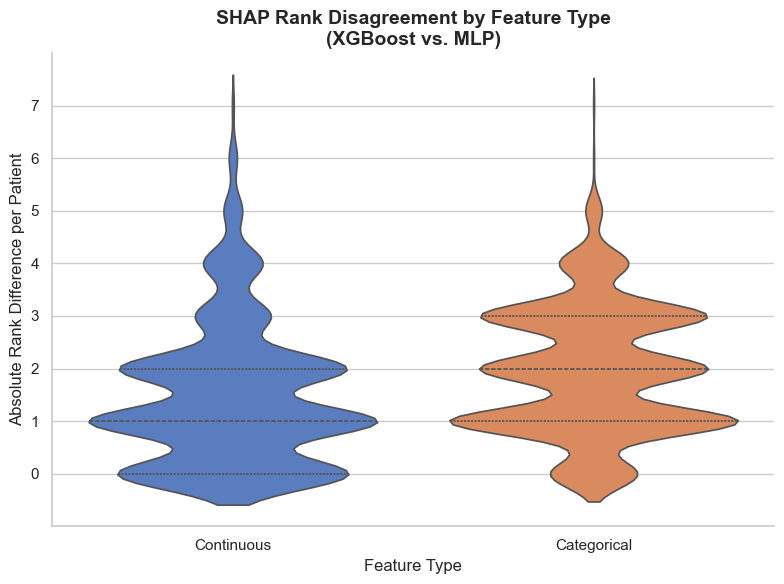


 Step 5: Feature Type Divergence for uci_heart
--- Step 5: Categorical vs. Continuous Divergence Analysis ---
Mean Rank Difference (Categorical): 4.42 positions
Mean Rank Difference (Continuous):  7.18 positions
Mann-Whitney U Statistic: 162300.0, p-value: 5.1743e-17

Conclusion: REJECT null hypothesis.
There is a statistically significant difference in how models rank categorical vs. continuous features.


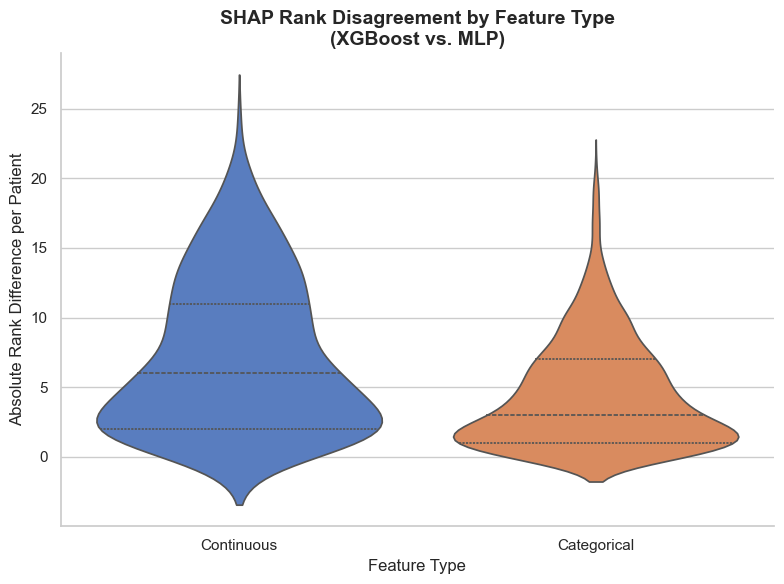


 Step 5: Feature Type Divergence for heart_disease_prediction
--- Step 5: Categorical vs. Continuous Divergence Analysis ---
Mean Rank Difference (Categorical): 4.00 positions
Mean Rank Difference (Continuous):  3.64 positions
Mann-Whitney U Statistic: 15151233.5, p-value: 4.6775e-13

Conclusion: REJECT null hypothesis.
There is a statistically significant difference in how models rank categorical vs. continuous features.


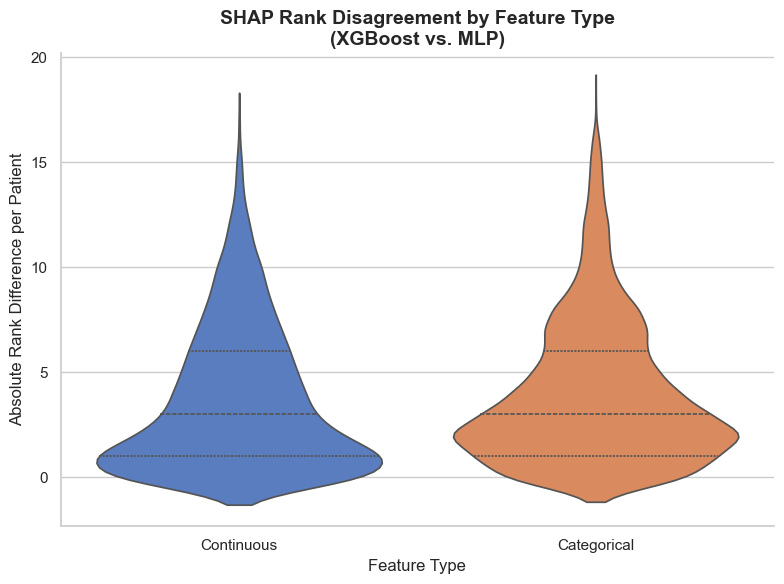

In [27]:
def analyze_feature_type_divergence(xgb_shap_values, mlp_shap_values, feature_names):
    """
    Analyzes whether SHAP explanation divergence is statistically tied to
    feature data types (categorical vs. continuous).

    Parameters:
    xgb_shap_values (np.ndarray): Local SHAP values from XGBoost (Shape: n_samples, n_features)
    mlp_shap_values (np.ndarray): Local SHAP values from MLP (Shape: n_samples, n_features)
    feature_names (list): List of feature names containing 'cat__' or 'num__' prefixes.
    """
    print("--- Step 5: Categorical vs. Continuous Divergence Analysis ---")

    n_samples, n_features = xgb_shap_values.shape
    records = []

    # Convert absolute SHAP values to Feature Ranks per patient (Scale-Invariant)
    # Rank 1 = Most important feature, Rank N = Least important feature
    for i in range(n_samples):
        # Use absolute SHAP values because magnitude indicates importance
        xgb_abs = np.abs(xgb_shap_values[i])
        mlp_abs = np.abs(mlp_shap_values[i])

        # Rank descending (highest abs SHAP gets rank 1)
        xgb_ranks = pd.Series(xgb_abs).rank(ascending=False, method='min').values
        mlp_ranks = pd.Series(mlp_abs).rank(ascending=False, method='min').values

        # Calculate absolute rank difference for this patient
        rank_diffs = np.abs(xgb_ranks - mlp_ranks)

        for j, feat in enumerate(feature_names):
            feat_type = 'Categorical' if feat.startswith('cat__') else 'Continuous' if feat.startswith('num__') else 'Other'

            if feat_type != 'Other':
                records.append({
                    'Patient_ID': i,
                    'Feature': feat,
                    'Feature_Type': feat_type,
                    'Rank_Difference': rank_diffs[j]
                })

    df_divergence = pd.DataFrame(records)

    # Statistical Testing (Mann-Whitney U Test)
    # Non-parametric test since rank differences are ordinal and likely skewed
    cat_diffs = df_divergence[df_divergence['Feature_Type'] == 'Categorical']['Rank_Difference']
    num_diffs = df_divergence[df_divergence['Feature_Type'] == 'Continuous']['Rank_Difference']

    stat, p_value = mannwhitneyu(cat_diffs, num_diffs, alternative='two-sided')

    # Report Findings
    print(f"Mean Rank Difference (Categorical): {cat_diffs.mean():.2f} positions")
    print(f"Mean Rank Difference (Continuous):  {num_diffs.mean():.2f} positions")
    print(f"Mann-Whitney U Statistic: {stat:.1f}, p-value: {p_value:.4e}")

    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion: REJECT null hypothesis.")
        print("There is a statistically significant difference in how models rank categorical vs. continuous features.")
    else:
        print("\nConclusion: FAIL TO REJECT null hypothesis.")
        print("No significant evidence that divergence is tied to feature type.")

    # Visualization
    plt.figure(figsize=(8, 6))
    sns.violinplot(
        data=df_divergence,
        x='Feature_Type',
        y='Rank_Difference',
        palette='muted',
        inner='quartile'
    )
    plt.title("SHAP Rank Disagreement by Feature Type\n(XGBoost vs. MLP)", fontsize=14, weight='bold')
    plt.ylabel("Absolute Rank Difference per Patient", fontsize=12)
    plt.xlabel("Feature Type", fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return df_divergence

# Dictionary to store the divergence results for each dataset
divergence_results = {}

for name, result in shap_results.items():
    print(f"\n{'='*60}")
    print(f" Step 5: Feature Type Divergence for {name}")
    print(f"{'='*60}")

    # Extract the arrays and feature lists generated in your SHAP pipeline
    xgb_shap = result["shap_xgb"]
    mlp_shap = result["shap_mlp"]
    feature_names = result["feature_names"]

    # Call the function for the current dataset
    df_div = analyze_feature_type_divergence(
        xgb_shap_values=xgb_shap,
        mlp_shap_values=mlp_shap,
        feature_names=feature_names
    )

    # Store the resulting DataFrame in case you need it for cross-dataset comparison later
    divergence_results[name] = df_div

### Cell 19: Explainer Robustness Check (KernelExplainer)
This step applies KernelExplainer to both models. # For each dataset, computes LOCAL mean Spearman ρ between |SHAP_xgb| and |SHAP_mlp| on the SAME seeded 50-patient subset, under two setups:
1. (A) TreeExplainer (XGB) + DeepExplainer (MLP)   — "Tree vs Deep"
2. (B) KernelExplainer    + KernelExplainer        — "Kernel vs Kernel"

This cell uses each model's own preprocessing and a seeded random subset shared across both explainer setups.


--- Running unified robustness for Pima Diabetes ---
{'Dataset': 'Pima Diabetes', 'Tree+Deep_local_rho': 0.6157, 'Kernel+Kernel_local_rho': 0.5881, 'Delta (Kernel − Tree+Deep)': -0.0276, 'n_patients': 50}

--- Running unified robustness for diabetes_prediction ---
{'Dataset': 'diabetes_prediction', 'Tree+Deep_local_rho': 0.5619, 'Kernel+Kernel_local_rho': 0.8757, 'Delta (Kernel − Tree+Deep)': 0.3138, 'n_patients': 50}

--- Running unified robustness for uci_heart ---
{'Dataset': 'uci_heart', 'Tree+Deep_local_rho': 0.7195, 'Kernel+Kernel_local_rho': 0.5579, 'Delta (Kernel − Tree+Deep)': -0.1616, 'n_patients': 50}

--- Running unified robustness for heart_disease_prediction ---
{'Dataset': 'heart_disease_prediction', 'Tree+Deep_local_rho': 0.6666, 'Kernel+Kernel_local_rho': 0.6117, 'Delta (Kernel − Tree+Deep)': -0.055, 'n_patients': 50}

=== Unified Explainer Robustness — USE THESE FOR SLIDE 16 ===
(Same 50 patients per dataset; only the explainer setup changes.)


,Dataset,Tree+Deep_local_rho,Kernel+Kernel_local_rho,Delta (Kernel − Tree+Deep),n_patients
0,Pima Diabetes,0.6157,0.5881,-0.0276,50
1,diabetes_prediction,0.5619,0.8757,0.3138,50
2,uci_heart,0.7195,0.5579,-0.1616,50
3,heart_disease_prediction,0.6666,0.6117,-0.0550,50


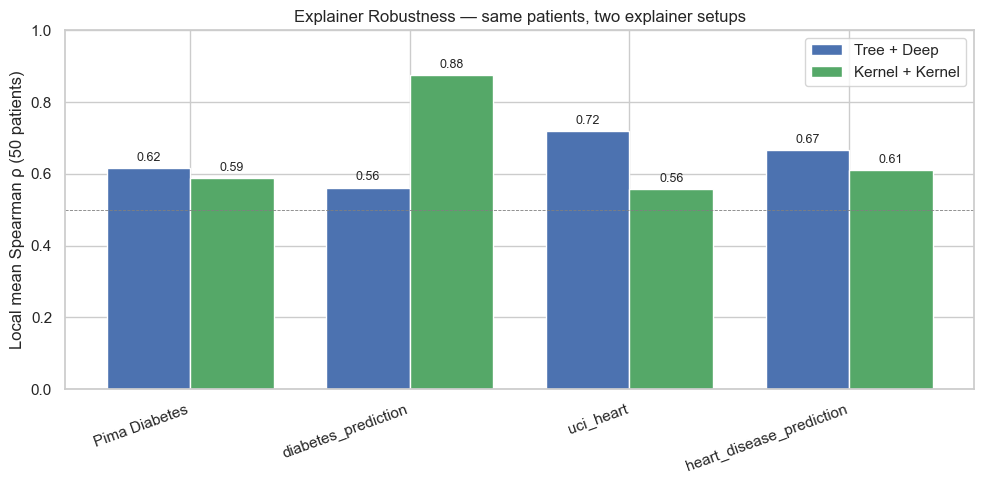

In [28]:
def _dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

def unified_robustness(name, model_bundle, split_data, preproc_pair,
                       sample_size=50, seed=42):
    xgb_model = model_bundle["xgb"]
    mlp_model = model_bundle["mlp"]

    # Reconstruct train-side preprocessed matrices (preprocessors are already fitted)
    X_train_raw = split_data["X_train"]
    X_train_xgb = _dense(preproc_pair["xgb"].transform(X_train_raw))
    X_train_mlp = _dense(preproc_pair["mlp"].transform(X_train_raw))
    X_test_xgb  = _dense(model_bundle["X_test_xgb"])
    X_test_mlp  = _dense(model_bundle["X_test_mlp"])

    # Seeded shared subset of test patients
    rng = np.random.default_rng(seed)
    s   = min(sample_size, len(X_test_mlp))
    idx = rng.choice(len(X_test_mlp), s, replace=False)
    X_xgb_sub = X_test_xgb[idx]
    X_mlp_sub = X_test_mlp[idx]

    # ---------- (A) TreeExplainer + DeepExplainer ----------
    tree_exp    = shap.TreeExplainer(xgb_model)
    sh_xgb_tree = tree_exp.shap_values(X_xgb_sub)
    if isinstance(sh_xgb_tree, list):
        sh_xgb_tree = sh_xgb_tree[1] if len(sh_xgb_tree) == 2 else sh_xgb_tree[0]
    sh_xgb_tree = np.asarray(sh_xgb_tree)
    if sh_xgb_tree.ndim == 3:
        sh_xgb_tree = sh_xgb_tree[..., -1]

    bg_mlp_tensor = torch.from_numpy(model_bundle["mlp_background"]).float()
    deep_exp      = shap.DeepExplainer(mlp_model, bg_mlp_tensor)
    sh_mlp_deep   = deep_exp.shap_values(torch.from_numpy(X_mlp_sub).float())
    if isinstance(sh_mlp_deep, list):
        sh_mlp_deep = sh_mlp_deep[1] if len(sh_mlp_deep) == 2 else sh_mlp_deep[0]
    sh_mlp_deep = np.asarray(sh_mlp_deep)
    if sh_mlp_deep.ndim == 3:
        sh_mlp_deep = sh_mlp_deep[..., -1]

    tree_deep_rhos = []
    for i in range(s):
        rho, _ = spearmanr(np.abs(sh_xgb_tree[i]), np.abs(sh_mlp_deep[i]))
        if not np.isnan(rho):
            tree_deep_rhos.append(rho)
    tree_deep_mean = float(np.mean(tree_deep_rhos))

    # ---------- (B) KernelExplainer + KernelExplainer ----------
    bg_xgb = shap.kmeans(X_train_xgb, 10)
    bg_mlp = shap.kmeans(X_train_mlp, 10)

    def xgb_proba(X):
        return xgb_model.predict_proba(X)[:, 1]

    def mlp_proba(X):
        mlp_model.eval()
        with torch.no_grad():
            out = mlp_model(torch.tensor(X, dtype=torch.float32)).cpu().numpy()
        if out.ndim > 1 and out.shape[1] > 1:
            return out[:, 1]
        return out.ravel()

    ke_xgb = shap.KernelExplainer(xgb_proba, bg_xgb)
    ke_mlp = shap.KernelExplainer(mlp_proba, bg_mlp)

    sh_xgb_kern = ke_xgb.shap_values(X_xgb_sub, silent=True)
    sh_mlp_kern = ke_mlp.shap_values(X_mlp_sub, silent=True)
    if isinstance(sh_xgb_kern, list): sh_xgb_kern = sh_xgb_kern[1]
    if isinstance(sh_mlp_kern, list): sh_mlp_kern = sh_mlp_kern[1]

    kernel_rhos = []
    for i in range(s):
        rho, _ = spearmanr(np.abs(sh_xgb_kern[i]), np.abs(sh_mlp_kern[i]))
        if not np.isnan(rho):
            kernel_rhos.append(rho)
    kernel_mean = float(np.mean(kernel_rhos))

    return {
        "Dataset":                  name,
        "Tree+Deep_local_rho":      round(tree_deep_mean, 4),
        "Kernel+Kernel_local_rho":  round(kernel_mean,    4),
        "Delta (Kernel − Tree+Deep)": round(kernel_mean - tree_deep_mean, 4),
        "n_patients":               s,
    }

unified_records = []
for name in ["Pima Diabetes", "diabetes_prediction",
             "uci_heart", "heart_disease_prediction"]:
    print(f"\n--- Running unified robustness for {name} ---")
    rec = unified_robustness(
        name           = name,
        model_bundle   = models[name],
        split_data     = splits[name],
        preproc_pair   = preprocessors[name],
        sample_size    = 50,
        seed           = 42,
    )
    print(rec)
    unified_records.append(rec)

unified_df = pd.DataFrame(unified_records)
print("\n=== Unified Explainer Robustness — USE THESE FOR SLIDE 16 ===")
print("(Same 50 patients per dataset; only the explainer setup changes.)")
display(unified_df)

# Quick bar chart for the slide
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(unified_df))
w = 0.38
ax.bar(x - w/2, unified_df["Tree+Deep_local_rho"],     w, label="Tree + Deep", color="#4C72B0")
ax.bar(x + w/2, unified_df["Kernel+Kernel_local_rho"], w, label="Kernel + Kernel", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(unified_df["Dataset"], rotation=20, ha="right")
ax.set_ylabel("Local mean Spearman ρ (50 patients)")
ax.set_title("Explainer Robustness — same patients, two explainer setups")
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.6)
ax.legend()
for i, row in unified_df.iterrows():
    ax.text(i - w/2, row["Tree+Deep_local_rho"] + 0.02,
            f"{row['Tree+Deep_local_rho']:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, row["Kernel+Kernel_local_rho"] + 0.02,
            f"{row['Kernel+Kernel_local_rho']:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()